# Machine Learning-Based Cross-Sectional Stock Selection for the S&P 500

**MSE 623 Final Project**

**Team:** Chenyu Liu · Yi Lu · Yukang Luo

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | **Imports & Configuration** — libraries, constants, output paths |
| 2 | **Data Loading** — daily OHLCV CSVs per stock from `archive/individual_stocks_5yr/` (2013–2017, ~500 tickers) |
| 3 | **Data Preprocessing** — drop missing/zero-price/zero-volume rows; verify coverage |
| 4 | **Feature Engineering** — 20 technical indicators computed at month-end per stock (11 base + 9 derived) |
| 5 | **Monthly Feature Dataset** — iterate all stocks × all months; cross-sectional pct-rank normalization; 3-month forward return target + binary label (top 10%) |
| 5a | **3-Step Feature Selection** — KS-test + IC filter → correlation deduplication → XGBoost permutation importance (training data only, no leakage) |
| 6 | **Expanding-Window Cross-Validation** — LR / RF / XGBoost, training on 2013→ and validating on each successive year (2014, 2015, 2016) |
| 7 | **Final Out-of-Sample Evaluation** — all models retrained on 2013–2016, tested on 2017 |
| 8 | **Ensemble Model** — within-month rank-averaged LR + RF + XGBoost scores |
| 9 | **Portfolio Construction & Evaluation** — quarterly non-overlapping formation (Jan/Apr/Jul/Oct); top-10% long vs equal-weighted benchmark; long-short (top − bottom 10%) |
| 10 | **Robustness Analysis** — feature importance (RF / XGBoost) |

---

**Key design choices (current version):**

| Dimension | Choice |
|-----------|--------|
| Universe | S&P 500 constituents with 5-year daily OHLCV (2013–2017) |
| Formation frequency | Monthly feature computation; **quarterly** portfolio rebalancing (Jan / Apr / Jul / Oct) |
| Features | 11 base OHLCV indicators + 9 engineered features (risk-adj. momentum, MA spread, volume term structure, interaction terms, log-volume, vol-of-vol, momentum z-score) |
| Feature normalization | **Cross-sectional percentile rank** within each month (robust to outliers; replaces z-score) |
| Feature selection | 3-step: KS+IC filter → correlation dedup → permutation importance (training years only) |
| Prediction target | Binary: top **10%** by 3-month forward return within each month |
| Validation | Expanding window (no look-ahead bias) |
| Ensemble | Rank-average of LR + RF + XGBoost (cross-sectional, month-aligned) |
| Portfolio evaluation | Non-overlapping quarterly windows → ~4 independent observations/year per metric |


## Step 1: Imports & Configuration

In [61]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [158]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier          # Classification task
from sklearn.metrics import (roc_auc_score,
                              mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost: available')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost: not installed – skipping XGBoost section')



def precision_at_k(y_true, y_score, k=0.1):
    """Fraction of true top-k% stocks among the model's top-k% picks."""
    n = len(y_score)
    top_k = max(1, int(np.ceil(n * k)))
    top_idx = np.argsort(y_score)[::-1][:top_k]
    return float(np.asarray(y_true)[top_idx].mean())

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
np.random.seed(42)

print('All libraries loaded.')

XGBoost: available
All libraries loaded.


## Step 2: Data Loading

We load all individual stock CSV files from the local archive.
Each file contains daily OHLCV data for one S&P 500 constituent (Feb 2013 – Feb 2018).

In [159]:

SCRIPT_DIR = os.getcwd()
DATA_PATH = os.path.join(SCRIPT_DIR, 'archive', 'individual_stocks_5yr')
OUT_DIR = SCRIPT_DIR

all_data = []
for file in sorted(os.listdir(DATA_PATH)):
    if file.endswith('.csv'):
        try:
            df = pd.read_csv(os.path.join(DATA_PATH, file))
            all_data.append(df)
        except Exception as e:
            print(f'  Warning: Could not load {file}: {e}')

data = pd.concat(all_data, ignore_index=True)
data.columns = [c.lower().strip() for c in data.columns]
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['name', 'date']).reset_index(drop=True)

print('=== Dataset Overview ===')
print(f'Total records  : {len(data):,}')
print(f'Unique tickers : {data["name"].nunique()}')
print(f'Date range     : {data["date"].min().date()} to {data["date"].max().date()}')
print(f'Columns        : {list(data.columns)}')
data.head()

=== Dataset Overview ===
Total records  : 619,040
Unique tickers : 505
Date range     : 2013-02-08 to 2018-02-07
Columns        : ['date', 'open', 'high', 'low', 'close', 'volume', 'name']


,date,open,high,low,close,volume,name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


In [160]:
# Data availability: unique tickers per year-month (pivot table)
ym = (data.assign(year=data['date'].dt.year, month=data['date'].dt.month)
         .groupby(['year', 'month'])['name'].nunique()
         .unstack('month'))
ym.columns = [f'M{m:02d}' for m in ym.columns]
print('Tickers with data per year-month (rows=year, cols=month):')
print(ym.to_string())
print(f'\nTotal year-month slices available: {int((ym > 0).sum().sum())}')

Tickers with data per year-month (rows=year, cols=month):
        M01    M02    M03    M04    M05    M06    M07    M08    M09    M10    M11    M12
year                                                                                    
2013    NaN  476.0  476.0  476.0  477.0  482.0  482.0  482.0  482.0  482.0  483.0  483.0
2014  483.0  483.0  484.0  485.0  485.0  486.0  487.0  487.0  488.0  488.0  488.0  488.0
2015  489.0  489.0  489.0  489.0  489.0  490.0  492.0  492.0  492.0  494.0  495.0  495.0
2016  496.0  496.0  496.0  497.0  497.0  497.0  498.0  498.0  498.0  498.0  498.0  499.0
2017  500.0  500.0  500.0  501.0  501.0  501.0  503.0  503.0  504.0  504.0  504.0  505.0
2018  505.0  505.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN

Total year-month slices available: 61


## Step 3: Data Preprocessing

- Remove rows with missing OHLCV values
- Remove rows with zero or negative prices / volume

In [161]:
print('Missing values before cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

data.dropna(subset=['open','high','low','close','volume'], inplace=True)
data = data[(data['close'] > 0) & (data['volume'] > 0) &
            (data['high'] > 0)  & (data['low'] > 0)].copy()
data.reset_index(drop=True, inplace=True)

print(f'\nRecords after cleaning: {len(data):,}')
print('Missing values after cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

Missing values before cleaning:
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Records after cleaning: 619,029
Missing values after cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


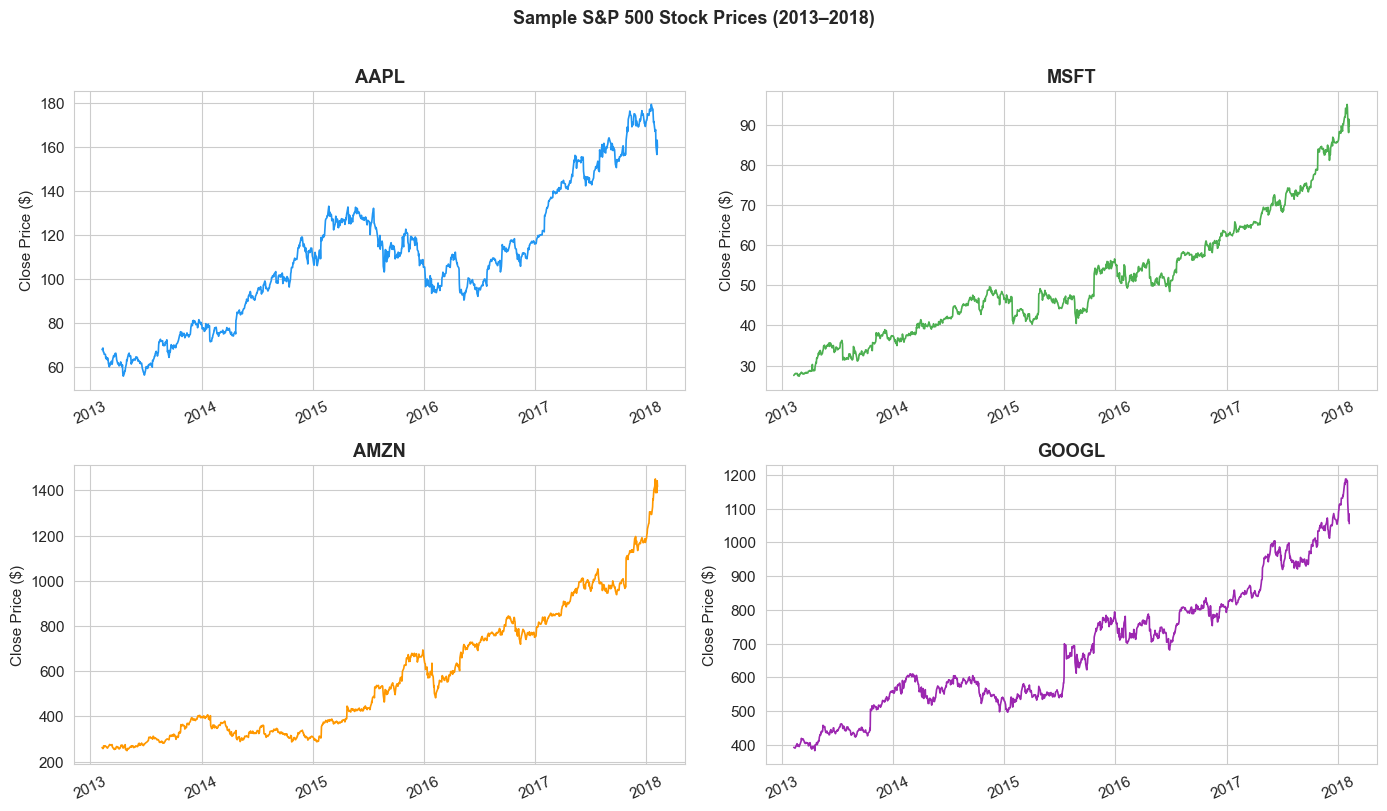

Saved: price_history.png


In [162]:
# Sample stock price histories
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, ticker, color in zip(axes.flat, sample_tickers, colors):
    stock = data[data['name'] == ticker]
    ax.plot(stock['date'], stock['close'], color=color, linewidth=1.2)
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Sample S&P 500 Stock Prices (2013–2018)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_history.png', bbox_inches='tight')
plt.show()
print('Saved: price_history.png')

## Step 4: Feature Engineering

We compute **12 technical indicators** at the **last trading day of each calendar month**.
All features are built solely from historical OHLCV data up to the formation date (no look-ahead).

| # | Feature | Definition |
|---|---------|-----------|
| 1 | `Momentum_1M` | Return over past 22 trading days |
| 2 | `Momentum_3M` | Return over past 64 trading days |
| 3 | `Price_to_MA20` | Close / 20-day moving average |
| 4 | `MA_20_slope` | OLS slope of the 20-day MA series |
| 5 | `Volatility_20d` | Std dev of 20-day daily returns |
| 6 | `High_Low_Range` | Day's High / Day's Low |
| 7 | `Volume_Ratio` | Day's volume / 20-day average volume |
| 8 | `1M_Accum_Vol_Change` | (Sum vol last 21d − prev 21d) / prev 21d |
| 9 | `RSI_14` | 14-day Relative Strength Index, normalised to [0, 1] |
| 10 | `BB_Position` | Bollinger Band position: (price − lower) / (upper − lower) |
| 11 | `High_52W_Ratio` | Close / 52-week high |
| 12 | `Short_Rev` | Negative of 1-week return (short-term reversal) |

After construction, each feature is **cross-sectionally ranked** within its formation month
(percentile rank 0–1 among all stocks in the same month), removing time-series level shifts.

In [163]:
FEATURE_COLS = [
    # --- Original 11 features (unchanged) ---
    'Momentum_1M', 'Momentum_3M', 'Momentum_6M',   # momentum at 1/3/6 months
    'Short_Rev',                                     # short-term reversal (1-week)
    'Price_to_MA20', 'Price_to_MA60',               # price vs short/medium MA
    'Volatility_20d', 'Volatility_60d',             # realised vol at 20/60 days
    'Volume_Ratio', '1M_Accum_Vol_Change',          # volume signal
    'High_52W_Ratio',                               # 52-week high proximity
    # --- New engineered features (9) ---
    'Mom_to_Vol',        # risk-adjusted momentum: momentum_1m / volatility_20d
    'Price_MA_Spread',   # short vs medium MA alignment: MA20 / MA60
    'Vol_MA_Ratio',      # volume term structure: 20d avg vol / 60d avg vol
    'Mom_Vol_Interact',  # momentum x volume: confirms trend with participation
    'Mom_52W_Interact',  # momentum x 52w-high ratio: trend + proximity
    'Log_Volume',        # log(last-day volume): compresses heavy right tail
    'Sqrt_Volatility',   # sqrt(volatility_20d): more symmetric distribution
    'Mom_Accel',         # momentum acceleration: momentum_1m - momentum_3m
    'Mom_LT_Diff',       # short vs long momentum: momentum_3m - momentum_6m
]


def _add_months(year, month, n):
    """Return (year, month) shifted forward by n calendar months."""
    m = month + n
    y = year + (m - 1) // 12
    m = (m - 1) % 12 + 1
    return y, m


def compute_features_for_stock_month(stock_df, year, month, min_history=127):
    """
    Compute 11 technical features at month-end for a given (year, month).

    TARGET CHANGE: Next_Return is now the 3-month forward cumulative return,
    i.e. (close at end of month+3) / (close at end of formation month) - 1.

    No look-ahead bias:
    - Features use strictly data up to the last trading day of `month`.
    - Label is derived from future data (month+1 through end of month+3).
    - The two windows do not overlap.

    Returns a feature dict or None if data is insufficient.
    """
    form_days = stock_df[
        (stock_df['date'].dt.year == year) & (stock_df['date'].dt.month == month)]

    # ── 3-month forward target window ─────────────────────────────────────────
    # Find last trading day close of month+3; used only for the label.
    tgt_year, tgt_month = _add_months(year, month, 3)
    tgt_days = stock_df[
        (stock_df['date'].dt.year == tgt_year) & (stock_df['date'].dt.month == tgt_month)]

    if len(form_days) < 10 or len(tgt_days) < 10:
        return None

    last_form_date    = form_days['date'].max()
    last_form_row     = form_days.loc[form_days['date'] == last_form_date].iloc[0]
    last_target_close = tgt_days.loc[
        tgt_days['date'] == tgt_days['date'].max(), 'close'].values[0]

    # Historical data strictly up to (and including) last_form_date — no look-ahead
    hist = stock_df[stock_df['date'] <= last_form_date].copy()
    if len(hist) < min_history:
        return None

    closes  = hist['close'].values.astype(float)
    volumes = hist['volume'].values.astype(float)

    if np.any(closes <= 0) or np.any(volumes <= 0):
        return None
    if len(closes) < 126 or len(volumes) < 42:
        return None

    daily_rets = closes[1:] / closes[:-1] - 1

    # ── Momentum features ─────────────────────────────────────────────────────
    # 1M momentum: cumulative return over last 22 trading days
    momentum_1m = (closes[-1] / closes[-22]) - 1
    # 3M momentum: cumulative return over last 64 trading days
    momentum_3m = (closes[-1] / closes[-64]) - 1
    # 6M momentum: cumulative return over last 126 trading days (medium-horizon trend)
    momentum_6m = (closes[-1] / closes[-126]) - 1
    # Short-term reversal: negative of 1-week return (mean-reversion signal)
    short_rev   = -((closes[-1] / closes[-6]) - 1) if len(closes) >= 6 else 0.0

    # ── Price / moving-average features ──────────────────────────────────────
    # Price relative to 20-day MA: short-term trend position
    ma20          = np.mean(closes[-20:])
    price_to_ma20 = closes[-1] / ma20
    # Price relative to 60-day MA: medium-term trend position (new)
    ma60          = np.mean(closes[-60:])
    price_to_ma60 = closes[-1] / ma60

    # ── Volatility features ───────────────────────────────────────────────────
    # 20-day realised volatility (std of daily returns)
    volatility_20d = np.std(daily_rets[-20:])
    # 60-day realised volatility: captures longer-horizon risk regime (new)
    volatility_60d = np.std(daily_rets[-60:])

    # ── Volume features ───────────────────────────────────────────────────────
    volume_ma20 = np.mean(volumes[-20:])
    if volume_ma20 == 0:
        return None
    # Volume ratio: last trading day's volume vs 20-day average volume
    volume_ratio     = float(last_form_row['volume']) / volume_ma20
    # 1M accumulated volume change: recent 21d vs prior 21d cumulative volume
    cum_vol_curr     = np.sum(volumes[-21:])
    cum_vol_prev     = np.sum(volumes[-42:-21])
    if cum_vol_prev == 0:
        return None
    accum_vol_change = (cum_vol_curr - cum_vol_prev) / cum_vol_prev

    # ── 52-week high ratio ────────────────────────────────────────────────────
    window_52w     = closes[-252:] if len(closes) >= 252 else closes
    high_52w_ratio = closes[-1] / np.max(window_52w)

    # --- Engineered features (derived from existing variables above) ---
    # Ratio: risk-adjusted momentum
    mom_to_vol = momentum_1m / (volatility_20d + 1e-8)
    # Ratio: short vs medium MA alignment
    price_ma_spread = price_to_ma20 / (price_to_ma60 + 1e-8)
    # Ratio: 20d avg vol / 60d avg vol (volume term structure)
    volume_ma60 = np.mean(volumes[-60:]) if len(volumes) >= 60 else np.mean(volumes)
    vol_ma_ratio = np.mean(volumes[-20:]) / (volume_ma60 + 1e-8)
    # Interaction: momentum confirmed by volume surge
    mom_vol_interact = momentum_1m * volume_ratio
    # Interaction: momentum toward 52-week high
    mom_52w_interact = momentum_1m * high_52w_ratio
    # Nonlinear: log of last-day volume (compresses right tail)
    log_volume = np.log(float(last_form_row['volume']) + 1.0)
    # Nonlinear: sqrt volatility (more symmetric)
    sqrt_volatility = np.sqrt(volatility_20d)
    # Time structure: 1M vs 3M momentum acceleration
    mom_accel = momentum_1m - momentum_3m
    # Time structure: 3M vs 6M momentum (trend persistence)
    mom_lt_diff = momentum_3m - momentum_6m

    # ── Target: 3-month forward cumulative return ─────────────────────────────
    # Label = (close at end of month+3) / (close at end of formation month) - 1
    # Features only use data <= last_form_date → no look-ahead bias guaranteed
    next_return = (last_target_close / closes[-1]) - 1

    return {
        'ticker':              stock_df['name'].iloc[0],
        'year':                year,
        'month':               month,
        'ym':                  year * 100 + month,
        'Momentum_1M':         momentum_1m,
        'Momentum_3M':         momentum_3m,
        'Momentum_6M':         momentum_6m,
        'Short_Rev':           short_rev,
        'Price_to_MA20':       price_to_ma20,
        'Price_to_MA60':       price_to_ma60,
        'Volatility_20d':      volatility_20d,
        'Volatility_60d':      volatility_60d,
        'Volume_Ratio':        volume_ratio,
        '1M_Accum_Vol_Change': accum_vol_change,
        'High_52W_Ratio':      high_52w_ratio,
        # New engineered features
        'Mom_to_Vol':        mom_to_vol,
        'Price_MA_Spread':   price_ma_spread,
        'Vol_MA_Ratio':      vol_ma_ratio,
        'Mom_Vol_Interact':  mom_vol_interact,
        'Mom_52W_Interact':  mom_52w_interact,
        'Log_Volume':        log_volume,
        'Sqrt_Volatility':   sqrt_volatility,
        'Mom_Accel':         mom_accel,
        'Mom_LT_Diff':       mom_lt_diff,
        'Next_Return':       next_return,
    }


print(f'Feature engineering functions ready.')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Feature engineering functions ready.
Features (20): ['Momentum_1M', 'Momentum_3M', 'Momentum_6M', 'Short_Rev', 'Price_to_MA20', 'Price_to_MA60', 'Volatility_20d', 'Volatility_60d', 'Volume_Ratio', '1M_Accum_Vol_Change', 'High_52W_Ratio', 'Mom_to_Vol', 'Price_MA_Spread', 'Vol_MA_Ratio', 'Mom_Vol_Interact', 'Mom_52W_Interact', 'Log_Volume', 'Sqrt_Volatility', 'Mom_Accel', 'Mom_LT_Diff']


## Step 5: Build Monthly Feature Dataset

We iterate over all stocks × all calendar months (2013–2017), computing features at each month-end.
This yields approximately **12× more training data** than using a single formation month per year.
A record is dropped if there are fewer than 65 historical trading days or fewer than 10 days in the
formation or target month.

In [164]:
YEARS  = list(range(2013, 2018))   # formation years
MONTHS = list(range(1, 13))        # all 12 months → 3-month forward return as target

tickers = data['name'].unique()

print(f'Building dataset: {len(tickers)} stocks x {len(YEARS)} years x 12 months')
print('(This may take 5–10 minutes...)\n')

records = []
for i, ticker in enumerate(tickers):
    stock_df = (data[data['name'] == ticker]
                .sort_values('date')
                .reset_index(drop=True))
    for year in YEARS:
        for month in MONTHS:
            rec = compute_features_for_stock_month(stock_df, year, month)
            if rec is not None:
                records.append(rec)
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(tickers)} stocks processed... ({len(records)} valid records)')

features_df = pd.DataFrame(records).dropna().reset_index(drop=True)

print(f'\n=== Feature Dataset ===')
print(f'Total valid observations: {len(features_df):,}')
print(f'\nObservations per year:')
print(features_df['year'].value_counts().sort_index().to_frame('count'))
features_df.head()

Building dataset: 505 stocks x 5 years x 12 months
(This may take 5–10 minutes...)

  100/505 stocks processed... (4919 valid records)
  200/505 stocks processed... (9786 valid records)
  300/505 stocks processed... (14714 valid records)
  400/505 stocks processed... (19740 valid records)
  500/505 stocks processed... (24722 valid records)

=== Feature Dataset ===
Total valid observations: 24,977

Observations per year:
      count
year       
2013   2387
2014   5800
2015   5861
2016   5939
2017   4990


,ticker,year,month,ym,Momentum_1M,Momentum_3M,Momentum_6M,Short_Rev,Price_to_MA20,Price_to_MA60,...,Mom_to_Vol,Price_MA_Spread,Vol_MA_Ratio,Mom_Vol_Interact,Mom_52W_Interact,Log_Volume,Sqrt_Volatility,Mom_Accel,Mom_LT_Diff,Next_Return
0,A,2013,8,201308,0.013032,0.024830,0.093296,0.021812,0.997903,1.028219,...,1.463300,0.970516,0.853066,0.007871,0.012671,14.121946,0.094372,-0.011798,-0.068466,0.148585
1,A,2013,9,201309,0.095085,0.175728,0.264808,0.008129,1.032662,1.081817,...,8.537469,0.954563,1.246279,0.077356,0.093444,14.790071,0.105534,-0.080643,-0.089079,0.115902
2,A,2013,10,201310,-0.015707,0.094437,0.208571,0.007042,0.988866,1.025385,...,-1.217699,0.964385,0.858565,-0.013359,-0.015046,14.454999,0.113573,-0.110144,-0.114134,0.145587
3,A,2013,11,201311,0.047312,0.148585,0.179436,0.009797,1.022279,1.043805,...,2.223033,0.979378,0.959718,0.015743,0.046140,13.676720,0.145885,-0.101273,-0.030851,0.062722
4,A,2013,12,201312,0.067575,0.101927,0.324763,0.006083,1.022848,1.074206,...,6.469553,0.952190,0.894115,0.031061,0.066758,13.755174,0.102201,-0.034352,-0.222836,-0.022207


## Step 5 (cont.): Cross-Sectional Feature Ranking

In [165]:
# Cross-sectional percentile ranking within each formation month.
# rank(pct=True) maps every feature to [0, 1] uniformly — robust to outliers.
# Replaces z-score normalization; no distributional assumptions needed.
# No look-ahead bias: each month is ranked independently.

for col in FEATURE_COLS:
    features_df[col] = features_df.groupby('ym')[col].rank(pct=True)

print('=== Features after Cross-Sectional Ranking ===')
print('Values are percentile ranks in [0, 1] within each formation month.\n')

# Verification: uniform distribution -> mean ≈ 0.5, std ≈ 0.289
ym_stats = features_df.groupby('ym')[FEATURE_COLS].agg(['mean', 'std'])
print('Per-month mean (expected ≈ 0.5):')
print(ym_stats.xs('mean', axis=1, level=1).mean().round(4).to_string())
print('\nPer-month std (expected ≈ 0.289):')
print(ym_stats.xs('std', axis=1, level=1).mean().round(4).to_string())


=== Features after Cross-Sectional Ranking ===
Values are percentile ranks in [0, 1] within each formation month.

Per-month mean (expected ≈ 0.5):
Momentum_1M            0.501
Momentum_3M            0.501
Momentum_6M            0.501
Short_Rev              0.501
Price_to_MA20          0.501
Price_to_MA60          0.501
Volatility_20d         0.501
Volatility_60d         0.501
Volume_Ratio           0.501
1M_Accum_Vol_Change    0.501
High_52W_Ratio         0.501
Mom_to_Vol             0.501
Price_MA_Spread        0.501
Vol_MA_Ratio           0.501
Mom_Vol_Interact       0.501
Mom_52W_Interact       0.501
Log_Volume             0.501
Sqrt_Volatility        0.501
Mom_Accel              0.501
Mom_LT_Diff            0.501

Per-month std (expected ≈ 0.289):
Momentum_1M            0.2890
Momentum_3M            0.2890
Momentum_6M            0.2890
Short_Rev              0.2890
Price_to_MA20          0.2890
Price_to_MA60          0.2890
Volatility_20d         0.2890
Volatility_60d         0.28

## Step 5 (cont.): Target Construction

**Regression target:** `Next_Return` — **3-month forward cumulative return**: (close at end of month+3) / (close at end of formation month) - 1.

**Binary target:** `Binary_Target` — 1 if the 3-month forward return is in the **top 10%** cross-sectionally within that (year, month), else 0.

Both the training label and the portfolio cutoff use the **top-10% threshold** (`quantile(0.9)` cross-sectionally within each month). At evaluation time, we select the stocks with the highest predicted probability scores.

In [166]:
# Binary cross-sectional target: within each (year, month) formation period,
# label the top 10% of stocks by Next_Return as 1, and the remaining 90% as 0.
#
# Both the training label and the portfolio cutoff use the top-10% threshold.
features_df['Binary_Target'] = (
    features_df.groupby('ym')['Next_Return']
    .transform(lambda x: (x >= x.quantile(0.9)).astype(int))
)

# --- Verification: label distribution should be ~10% positives per month ---
print('=== Binary Target Distribution — proportion of positives per month (training label: top 10%) ===')
print(features_df.groupby('ym')['Binary_Target'].mean().head(10).round(4))

print('\n=== Binary Target Distribution per year (count of 0s and 1s) ===')
print(features_df.groupby('year')['Binary_Target'].value_counts().unstack())

print('\n=== Stocks per month: total, labeled-1, and proportion ===')
check = features_df.groupby('ym')['Binary_Target'].agg(
    total='count',
    positives='sum'
)
check['proportion'] = check['positives'] / check['total']
print(check.head(10).round(4))

print('\n=== 3-Month Forward Return Statistics by Year ===')
print(features_df.groupby('year')['Next_Return'].describe().round(4))

=== Binary Target Distribution — proportion of positives per month (training label: top 10%) ===
ym
201308    0.1008
201309    0.1008
201310    0.1008
201311    0.1006
201312    0.1017
201401    0.1017
201402    0.1017
201403    0.1017
201404    0.1017
201405    0.1014
Name: Binary_Target, dtype: float64

=== Binary Target Distribution per year (count of 0s and 1s) ===
Binary_Target     0    1
year                    
2013           2146  241
2014           5212  588
2015           5273  588
2016           5339  600
2017           4489  501

=== Stocks per month: total, labeled-1, and proportion ===
        total  positives  proportion
ym                                  
201308    476         48      0.1008
201309    476         48      0.1008
201310    476         48      0.1008
201311    477         48      0.1006
201312    482         49      0.1017
201401    482         49      0.1017
201402    482         49      0.1017
201403    482         49      0.1017
201404    482         4

## Step 5 (cont.): Exploratory Data Analysis

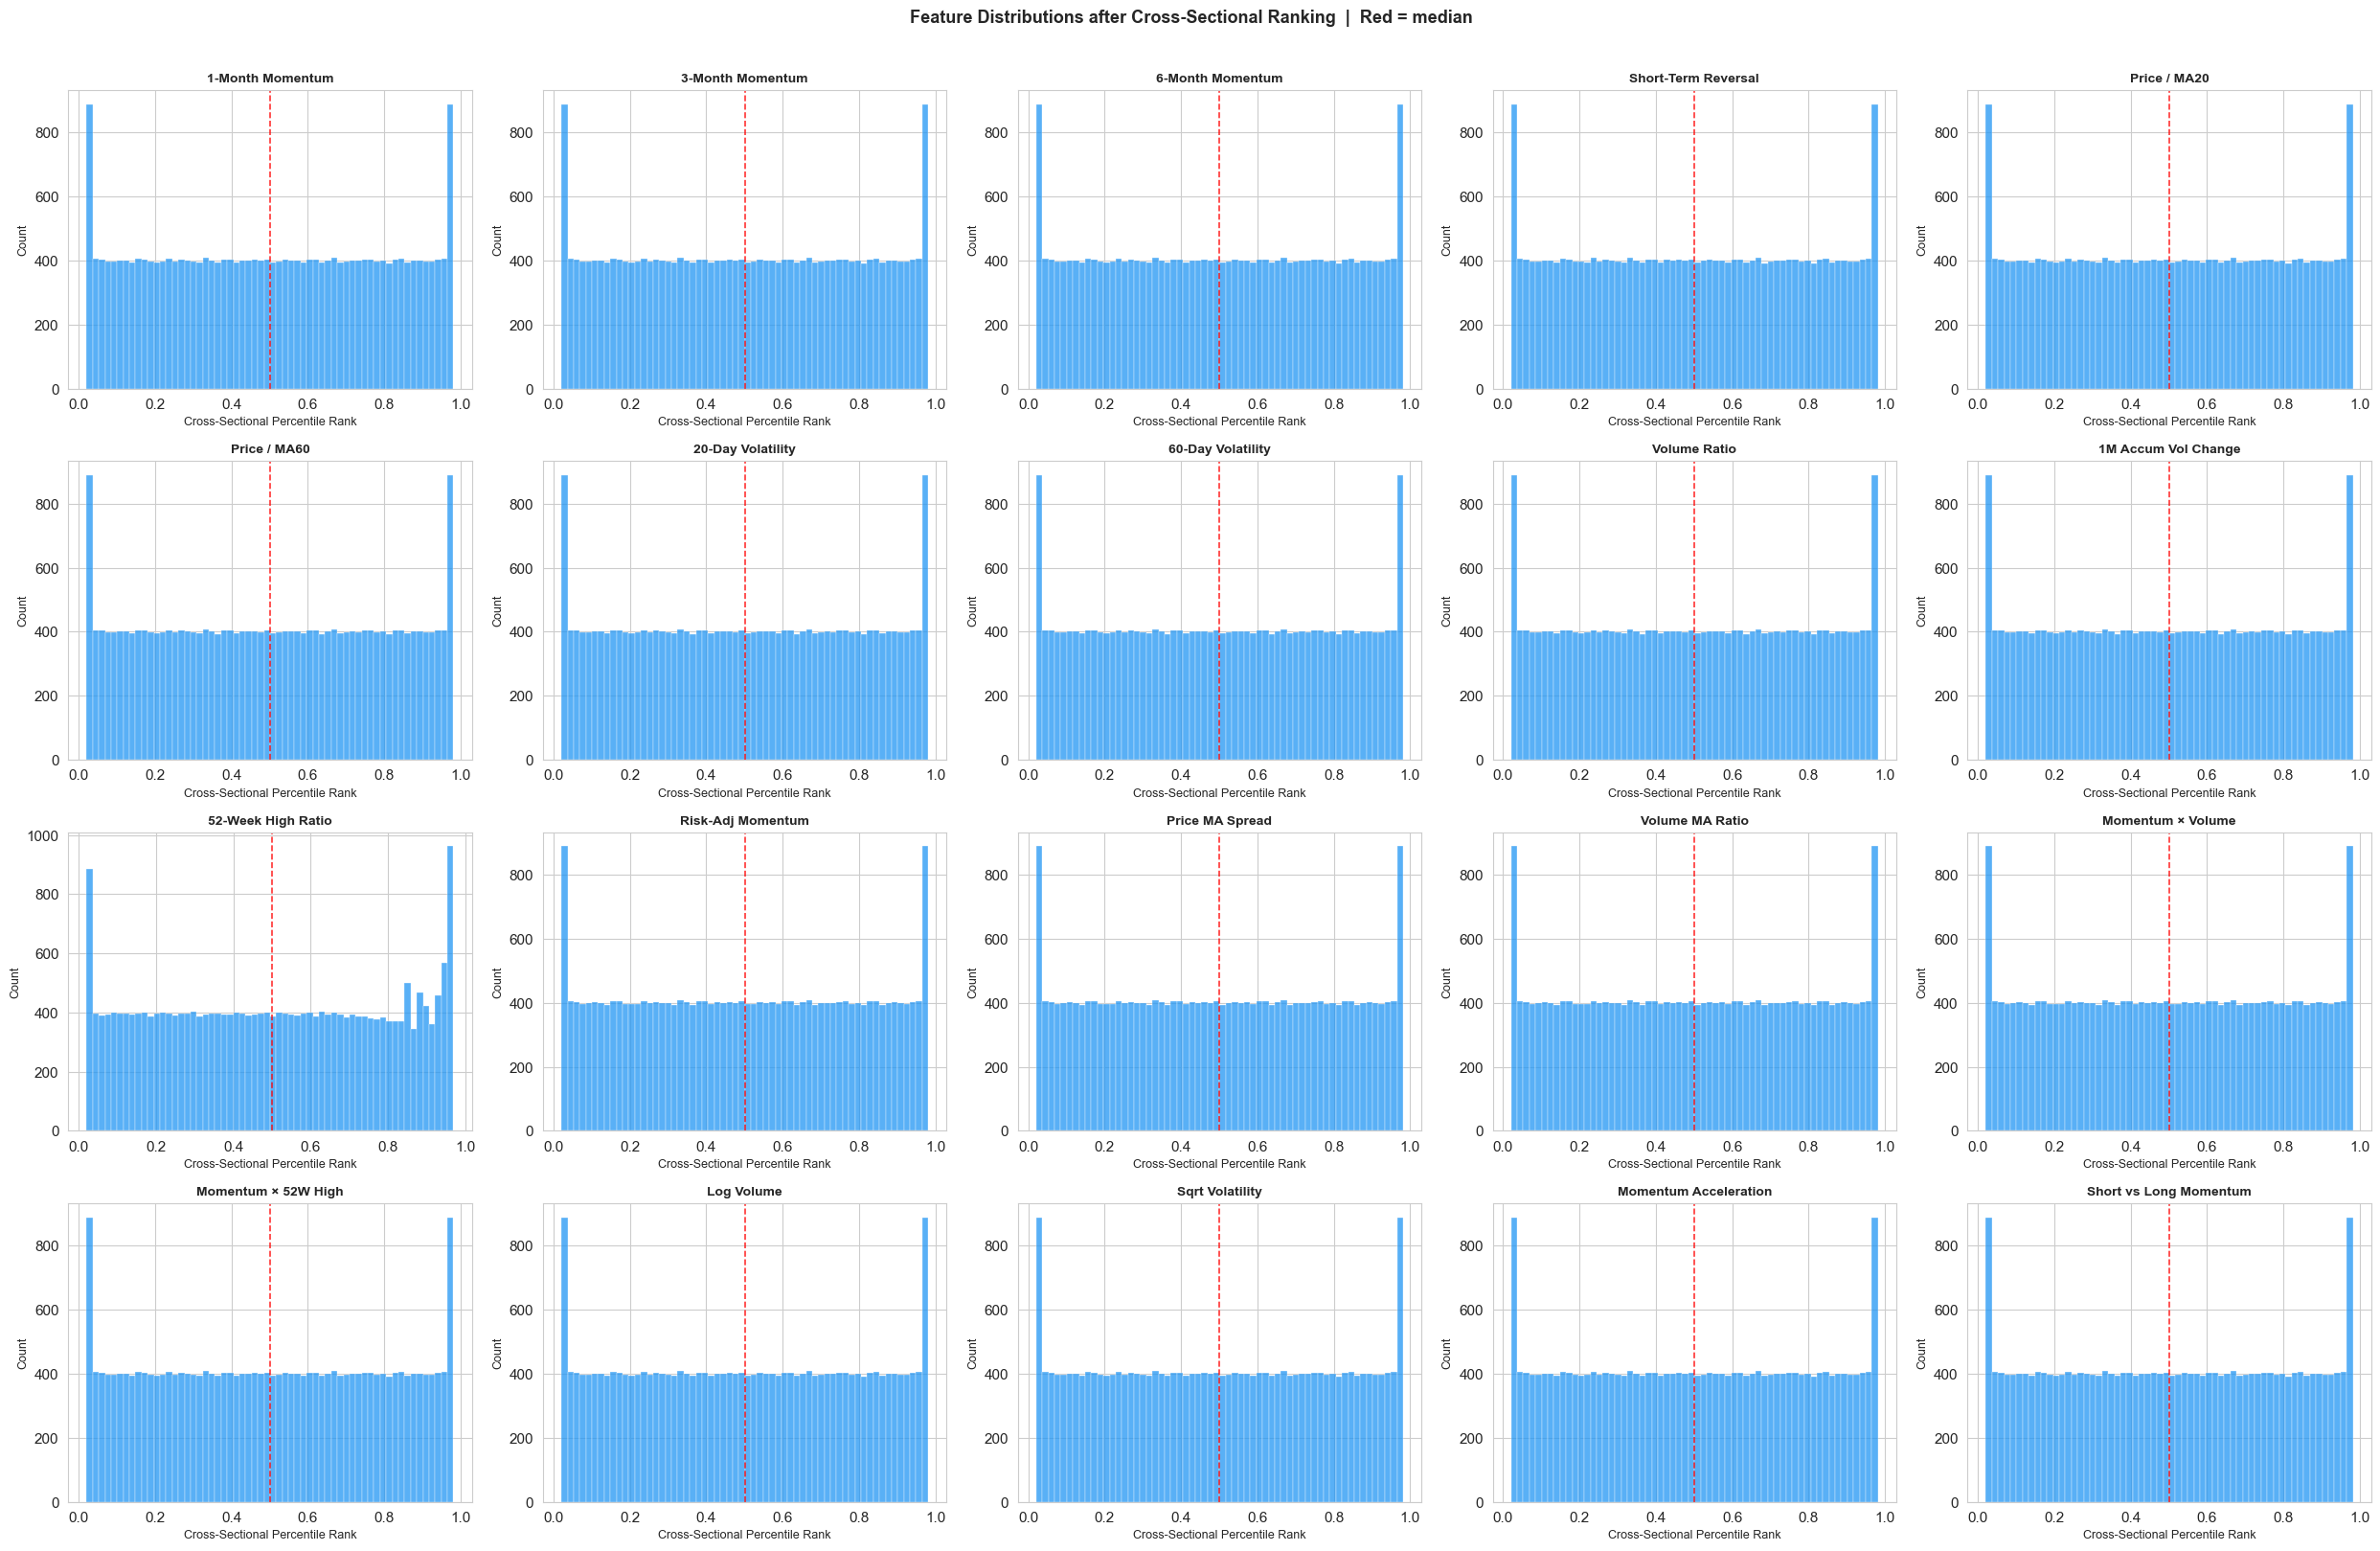

Saved: feature_distributions.png


In [167]:
feature_labels = {
    # Original 11
    'Momentum_1M':         '1-Month Momentum',
    'Momentum_3M':         '3-Month Momentum',
    'Momentum_6M':         '6-Month Momentum',
    'Short_Rev':           'Short-Term Reversal',
    'Price_to_MA20':       'Price / MA20',
    'Price_to_MA60':       'Price / MA60',
    'Volatility_20d':      '20-Day Volatility',
    'Volatility_60d':      '60-Day Volatility',
    'Volume_Ratio':        'Volume Ratio',
    '1M_Accum_Vol_Change': '1M Accum Vol Change',
    'High_52W_Ratio':      '52-Week High Ratio',
    # New engineered 9
    'Mom_to_Vol':          'Risk-Adj Momentum',
    'Price_MA_Spread':     'Price MA Spread',
    'Vol_MA_Ratio':        'Volume MA Ratio',
    'Mom_Vol_Interact':    'Momentum × Volume',
    'Mom_52W_Interact':    'Momentum × 52W High',
    'Log_Volume':          'Log Volume',
    'Sqrt_Volatility':     'Sqrt Volatility',
    'Mom_Accel':           'Momentum Acceleration',
    'Mom_LT_Diff':         'Short vs Long Momentum',
}

fig, axes = plt.subplots(4, 5, figsize=(25, 16))  # 4×5 = 20 subplots, perfect fit
for ax, (col, label) in zip(axes.flat, feature_labels.items()):
    vals = features_df[col].clip(features_df[col].quantile(0.02),
                                 features_df[col].quantile(0.98))
    ax.hist(vals, bins=60, color='#2196F3', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Cross-Sectional Percentile Rank', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.suptitle('Feature Distributions after Cross-Sectional Ranking  |  Red = median',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

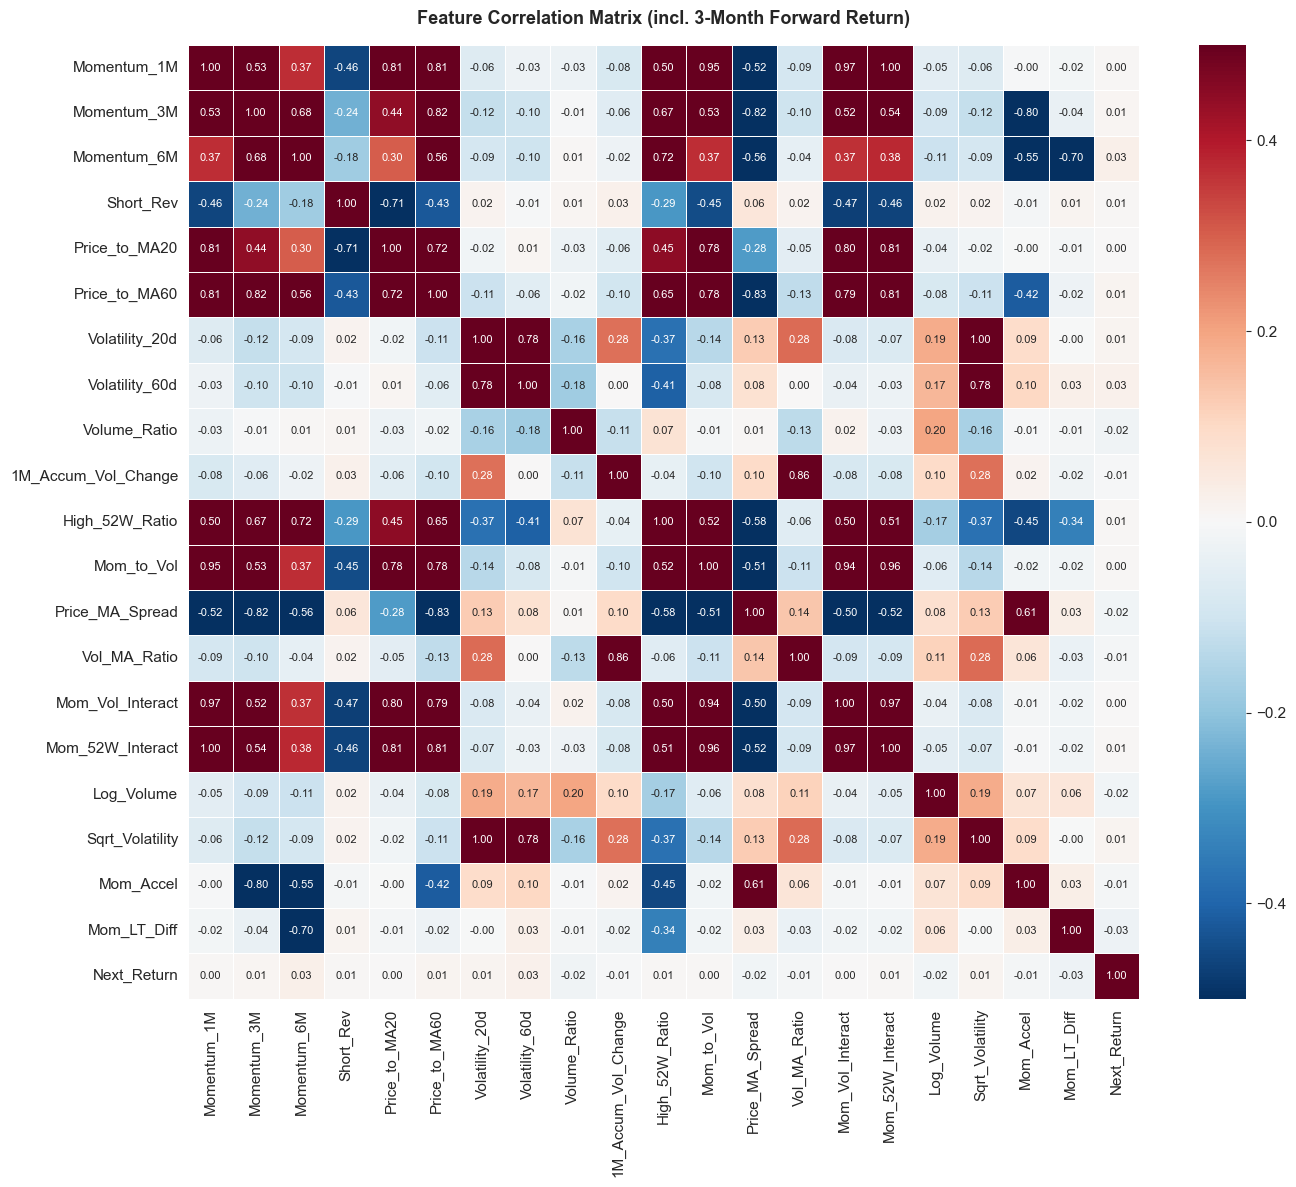

Saved: feature_correlation.png


In [168]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_df[FEATURE_COLS + ['Next_Return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.5, vmax=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (incl. 3-Month Forward Return)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: feature_correlation.png')

In [169]:
# ============================================================
# 3-Step Feature Selection Pipeline
# Uses ONLY training years (2013-2016) — no test-data leakage.
# Updates FEATURE_COLS in-place; all downstream cells pick it up automatically.
# ============================================================
from scipy.stats import ks_2samp, spearmanr
from sklearn.inspection import permutation_importance

train_df = features_df[features_df['year'] < 2017].copy()
ym_list  = sorted(train_df['ym'].unique())

ks_scores = {col: [] for col in FEATURE_COLS}
ic_scores  = {col: [] for col in FEATURE_COLS}

# --- Step 1: Univariate Filter — per-month KS + Spearman IC ---
for ym_val in ym_list:
    month_df = train_df[train_df['ym'] == ym_val]
    top_mask = month_df['Binary_Target'] == 1
    if top_mask.sum() < 3:
        continue
    for col in FEATURE_COLS:
        top_vals  = month_df.loc[top_mask,  col].dropna().values
        rest_vals = month_df.loc[~top_mask, col].dropna().values
        if len(top_vals) > 1 and len(rest_vals) > 1:
            ks, _ = ks_2samp(top_vals, rest_vals)
            ks_scores[col].append(ks)
        ret_vals  = month_df['Next_Return'].values
        feat_vals = month_df[col].values
        valid = ~(np.isnan(feat_vals) | np.isnan(ret_vals))
        if valid.sum() > 5:
            ic, _ = spearmanr(feat_vals[valid], ret_vals[valid])
            ic_scores[col].append(ic)

ks_mean = {col: np.mean(v) for col, v in ks_scores.items() if v}
ic_mean = {col: np.mean(v) for col, v in ic_scores.items() if v}
ic_ir   = {col: np.mean(v) / (np.std(v) + 1e-8) for col, v in ic_scores.items() if v}

# Keep: KS >= median AND |mean IC| >= 0.01
ks_threshold = np.median(list(ks_mean.values()))
filter_pass  = [col for col in FEATURE_COLS
                if ks_mean.get(col, 0) >= ks_threshold
                and abs(ic_mean.get(col, 0)) >= 0.01]
print(f'Step 1 Univariate Filter:      {len(FEATURE_COLS)} -> {len(filter_pass)} features')

# --- Step 2: De-correlation — corr > 0.8: drop lower-KS feature ---
corr_matrix = train_df[filter_pass].corr().abs()
to_drop = set()
for i, col_a in enumerate(filter_pass):
    if col_a in to_drop:
        continue
    for col_b in filter_pass[i + 1:]:
        if col_b in to_drop:
            continue
        if corr_matrix.loc[col_a, col_b] > 0.8:
            drop = col_a if ks_mean.get(col_a, 0) < ks_mean.get(col_b, 0) else col_b
            to_drop.add(drop)

dedup_pass = [col for col in filter_pass if col not in to_drop]
print(f'Step 2 De-correlation:         {len(filter_pass)} -> {len(dedup_pass)} features')

# --- Step 3: Permutation Importance — select top 10-20 features ---
X_sel = train_df[dedup_pass].fillna(0.5).values
y_sel = train_df['Binary_Target'].values

if XGB_AVAILABLE:
    import xgboost as xgb
    sel_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0)
else:
    from sklearn.ensemble import RandomForestClassifier
    sel_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

sel_model.fit(X_sel, y_sel)
perm = permutation_importance(sel_model, X_sel, y_sel,
                               n_repeats=5, random_state=42, scoring='roc_auc')
perm_mean = dict(zip(dedup_pass, perm.importances_mean))
ranked_feats = sorted(dedup_pass, key=lambda c: perm_mean[c], reverse=True)

N_SELECT     = min(20, max(10, len(ranked_feats)))
FEATURE_COLS = ranked_feats[:N_SELECT]

print(f'Step 3 Permutation Importance: {len(dedup_pass)} -> {len(FEATURE_COLS)} features')
print(f'\nFinal FEATURE_COLS ({len(FEATURE_COLS)}):')
print(f"  {'Feature':<25}  {'KS':>6}  {'IC':>7}  {'IC_IR':>7}  {'PermImp':>8}")
print('  ' + '-' * 58)
for col in FEATURE_COLS:
    print(f"  {col:<25}  {ks_mean.get(col,0):>6.4f}  {ic_mean.get(col,0):>7.4f}"
          f"  {ic_ir.get(col,0):>7.3f}  {perm_mean[col]:>8.5f}")


Step 1 Univariate Filter:      20 -> 9 features
Step 2 De-correlation:         9 -> 6 features
Step 3 Permutation Importance: 6 -> 6 features

Final FEATURE_COLS (6):
  Feature                        KS       IC    IC_IR   PermImp
  ----------------------------------------------------------
  Volatility_60d             0.3138   0.0309    0.160   0.13085
  Volatility_20d             0.2745   0.0115    0.066   0.08887
  High_52W_Ratio             0.2203  -0.0206   -0.105   0.07151
  Mom_Accel                  0.2044   0.0100    0.063   0.05732
  Price_MA_Spread            0.2131   0.0173    0.094   0.05669
  Momentum_1M                0.2062  -0.0224   -0.132   0.04231


## Step 6: Time-Series Cross-Validation (Expanding Window)

To prevent **look-ahead bias**, we use an expanding-window scheme where the validation year
always comes after all training years.

Each year now contributes ~12 months × ~450 stocks ≈ **5,400 observations**,
giving substantially more training signal than the previous single-month-per-year approach.

| Fold | Training years | Validation year | Approx. train obs |
|------|----------------|-----------------|-------------------|
| 1 | 2013 | 2014 | ~5,400 |
| 2 | 2013–2014 | 2015 | ~10,800 |
| 3 | 2013–2015 | 2016 | ~16,200 |

**Final test:** trained on 2013–2016 (~21,600 obs), evaluated on 2017.

In [170]:
CV_FOLDS = [
    ([2013],             2014),
    ([2013, 2014],       2015),
    ([2013, 2014, 2015], 2016),
]
FINAL_TRAIN_YEARS = [2013, 2014, 2015, 2016]
TEST_YEAR = 2017


def get_split(df, train_years, val_year):
    """Return train/val arrays and the full val DataFrame."""
    tr = df[df['year'].isin(train_years)]
    va = df[df['year'] == val_year]
    return (
        tr[FEATURE_COLS].values,
        tr['Next_Return'].values,
        tr['Binary_Target'].values,
        va[FEATURE_COLS].values,
        va['Next_Return'].values,
        va['Binary_Target'].values,
        va.reset_index(drop=True),
    )


print('Expanding-window CV structure:')
print('-' * 65)
for train_yrs, val_yr in CV_FOLDS:
    n_tr = len(features_df[features_df['year'].isin(train_yrs)])
    n_va = len(features_df[features_df['year'] == val_yr])
    print(f'  Train: {train_yrs}  ({n_tr:,} obs)  ->  Val: {val_yr}  ({n_va:,} obs)')
n_te = len(features_df[features_df['year'] == TEST_YEAR])
print(f'  Final test: {TEST_YEAR}  ({n_te:,} obs)')
print('-' * 65)

Expanding-window CV structure:
-----------------------------------------------------------------
  Train: [2013]  (2,387 obs)  ->  Val: 2014  (5,800 obs)
  Train: [2013, 2014]  (8,187 obs)  ->  Val: 2015  (5,861 obs)
  Train: [2013, 2014, 2015]  (14,048 obs)  ->  Val: 2016  (5,939 obs)
  Final test: 2017  (4,990 obs)
-----------------------------------------------------------------


### 6.1 Logistic Regression — Cross-Validation

We search over the regularisation strength **C** (inverse of L2 penalty).
Smaller C → stronger regularisation; larger C → closer fit to training data.

In [171]:
print('=' * 65)
print('LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)')
print('=' * 65)

LR_C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0]
lr_c_aucs = {C: [] for C in LR_C_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)
    for C in LR_C_GRID:
        lr = LogisticRegression(C=C, max_iter=2000, random_state=42, solver='lbfgs')
        lr.fit(X_tr_sc, y_tr_c)
        prob = lr.predict_proba(X_va_sc)[:, 1]
        lr_c_aucs[C].append(roc_auc_score(y_va_c, prob))

lr_avg_aucs = {C: np.mean(v) for C, v in lr_c_aucs.items()}
BEST_C_LR = max(lr_avg_aucs, key=lr_avg_aucs.get)

print(f'  {"C":>8} | {"Fold1":>8} | {"Fold2":>8} | {"Fold3":>8} | {"Avg AUC":>8}')
print('  ' + '-' * 52)
for C in LR_C_GRID:
    aucs = lr_c_aucs[C]
    marker = '  <- BEST' if C == BEST_C_LR else ''
    print(f'  {C:>8.3f} | {aucs[0]:>8.4f} | {aucs[1]:>8.4f} | {aucs[2]:>8.4f} | '
          f'{np.mean(aucs):>8.4f}{marker}')
print(f'\nSelected C = {BEST_C_LR}')

LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)
         C |    Fold1 |    Fold2 |    Fold3 |  Avg AUC
  ----------------------------------------------------
     0.001 |   0.6679 |   0.5603 |   0.7228 |   0.6503
     0.010 |   0.6716 |   0.5589 |   0.7241 |   0.6515
     0.100 |   0.6735 |   0.5579 |   0.7244 |   0.6519  <- BEST
     1.000 |   0.6731 |   0.5577 |   0.7243 |   0.6517
    10.000 |   0.6731 |   0.5577 |   0.7243 |   0.6517

Selected C = 0.1


In [172]:
print(f'\nLogistic Regression CV Results  (C={BEST_C_LR})')
print('-' * 50)

lr_cv_results = []
lr_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    lr = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
    lr.fit(X_tr_sc, y_tr_c)
    prob = lr.predict_proba(X_va_sc)[:, 1]
    prec = precision_at_k(y_va_c, prob)
    auc = roc_auc_score(y_va_c, prob)
    lr_cv_results.append({'val_year': val_yr, 'prec_at_k': prec, 'auc': auc})
    # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
    lr_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Prec@10% = {prec:.4f}  |  AUC = {auc:.4f}')

lr_cv_df = pd.DataFrame(lr_cv_results)
print(f'\n  Mean Prec@10% : {lr_cv_df.prec_at_k.mean():.4f} +/- {lr_cv_df.prec_at_k.std():.4f}')
print(f'  Mean AUC      : {lr_cv_df.auc.mean():.4f} +/- {lr_cv_df.auc.std():.4f}')


Logistic Regression CV Results  (C=0.1)
--------------------------------------------------
  Val 2014:  Prec@10% = 0.2414  |  AUC = 0.6735
  Val 2015:  Prec@10% = 0.1431  |  AUC = 0.5579
  Val 2016:  Prec@10% = 0.2946  |  AUC = 0.7244

  Mean Prec@10% : 0.2264 +/- 0.0769
  Mean AUC      : 0.6519 +/- 0.0853


### 6.2 Random Forest — Cross-Validation

In [173]:
print('=' * 65)
print('RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)')
print('=' * 65)

RF_PARAM_GRID = list(product([3, 5, 7], [5, 10]))  # max_depth, min_samples_leaf
rf_param_aucs = {p: [] for p in RF_PARAM_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    for max_d, min_leaf in RF_PARAM_GRID:
        # Use RandomForestClassifier with Binary_Target
        rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                    min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_c)
        prob = rf.predict_proba(X_va)[:, 1]
        rf_param_aucs[(max_d, min_leaf)].append(roc_auc_score(y_va_c, prob))

rf_avg_aucs  = {p: np.mean(v) for p, v in rf_param_aucs.items()}
BEST_PARAMS_RF = max(rf_avg_aucs, key=rf_avg_aucs.get)

print(f'  {"max_depth":>10} | {"min_leaf":>8} | {"Fold1":>10} | {"Fold2":>10} | '
      f'{"Fold3":>10} | {"Avg AUC":>10}')
print('  ' + '-' * 68)
for (max_d, min_leaf) in RF_PARAM_GRID:
    aucs   = rf_param_aucs[(max_d, min_leaf)]
    marker = '  <- BEST' if (max_d, min_leaf) == BEST_PARAMS_RF else ''
    print(f'  {max_d:>10} | {min_leaf:>8} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
          f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
print(f'\nSelected: max_depth={BEST_PARAMS_RF[0]}, min_samples_leaf={BEST_PARAMS_RF[1]}')

RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)
   max_depth | min_leaf |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  --------------------------------------------------------------------
           3 |        5 |     0.6600 |     0.5718 |     0.7186 |     0.6501
           3 |       10 |     0.6622 |     0.5718 |     0.7190 |     0.6510  <- BEST
           5 |        5 |     0.6587 |     0.5710 |     0.7167 |     0.6488
           5 |       10 |     0.6605 |     0.5699 |     0.7177 |     0.6493
           7 |        5 |     0.6526 |     0.5651 |     0.7113 |     0.6430
           7 |       10 |     0.6540 |     0.5654 |     0.7102 |     0.6432

Selected: max_depth=3, min_samples_leaf=10


In [174]:
print(f'\nRandom Forest CV Results  (max_depth={BEST_PARAMS_RF[0]}, '
      f'min_leaf={BEST_PARAMS_RF[1]})')
print('-' * 50)

rf_cv_results = []
rf_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    max_d, min_leaf = BEST_PARAMS_RF
    # RandomForestClassifier trained on Binary_Target
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr_c)
    prob = rf.predict_proba(X_va)[:, 1]   # probability of being in top-10% (training label threshold)
    prec = precision_at_k(y_va_c, prob)
    auc = roc_auc_score(y_va_c, prob)
    rf_cv_results.append({'val_year': val_yr, 'prec_at_k': prec, 'auc': auc})
    # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
    rf_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Prec@10% = {prec:.4f}  |  AUC = {auc:.4f}')

rf_cv_df = pd.DataFrame(rf_cv_results)
print(f'\n  Mean Prec@10% : {rf_cv_df.prec_at_k.mean():.4f} +/- {rf_cv_df.prec_at_k.std():.4f}')
print(f'  Mean AUC      : {rf_cv_df.auc.mean():.4f} +/- {rf_cv_df.auc.std():.4f}')


Random Forest CV Results  (max_depth=3, min_leaf=10)
--------------------------------------------------
  Val 2014:  Prec@10% = 0.2431  |  AUC = 0.6622
  Val 2015:  Prec@10% = 0.1618  |  AUC = 0.5718
  Val 2016:  Prec@10% = 0.2896  |  AUC = 0.7190

  Mean Prec@10% : 0.2315 +/- 0.0646
  Mean AUC      : 0.6510 +/- 0.0742


### 6.3 XGBoost — Cross-Validation

In [175]:
if XGB_AVAILABLE:
    print('=' * 65)
    print('XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)')
    print('=' * 65)

    XGB_PARAM_GRID = list(product([3, 5], [0.05, 0.1]))  # max_depth, learning_rate
    xgb_param_aucs = {p: [] for p in XGB_PARAM_GRID}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
            features_df, train_yrs, val_yr)
        for max_d, lr in XGB_PARAM_GRID:
            # XGBClassifier trained on Binary_Target
            model = xgb.XGBClassifier(
                n_estimators=100, max_depth=max_d, learning_rate=lr,
                use_label_encoder=False, eval_metric='logloss', random_state=42)
            model.fit(X_tr, y_tr_c)
            prob = model.predict_proba(X_va)[:, 1]
            xgb_param_aucs[(max_d, lr)].append(roc_auc_score(y_va_c, prob))

    xgb_avg_aucs   = {p: np.mean(v) for p, v in xgb_param_aucs.items()}
    BEST_PARAMS_XGB = max(xgb_avg_aucs, key=xgb_avg_aucs.get)

    print(f'  {"max_depth":>10} | {"lr":>8} | {"Fold1":>10} | {"Fold2":>10} | '
          f'{"Fold3":>10} | {"Avg AUC":>10}')
    print('  ' + '-' * 66)
    for (max_d, lr) in XGB_PARAM_GRID:
        aucs   = xgb_param_aucs[(max_d, lr)]
        marker = '  <- BEST' if (max_d, lr) == BEST_PARAMS_XGB else ''
        print(f'  {max_d:>10} | {lr:>8.2f} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
              f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
    print(f'\nSelected: max_depth={BEST_PARAMS_XGB[0]}, learning_rate={BEST_PARAMS_XGB[1]}')

    # ── CV results with best params ───────────────────────────────────────────
    print(f'\nXGBoost CV Results  (max_depth={BEST_PARAMS_XGB[0]}, '
          f'lr={BEST_PARAMS_XGB[1]})')
    print('-' * 50)

    xgb_cv_results = []
    xgb_val_preds  = {}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
            features_df, train_yrs, val_yr)
        max_d, lr = BEST_PARAMS_XGB
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=max_d, learning_rate=lr,
            use_label_encoder=False, eval_metric='logloss', random_state=42)
        model.fit(X_tr, y_tr_c)
        prob = model.predict_proba(X_va)[:, 1]
        prec = precision_at_k(y_va_c, prob)
        auc = roc_auc_score(y_va_c, prob)
        xgb_cv_results.append({'val_year': val_yr, 'prec_at_k': prec, 'auc': auc})
        # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
        xgb_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                                  'score':   prob,
                                  'actual':  y_va_r,
                                  'ym':      va_df['ym'].values}
        print(f'  Val {val_yr}:  Prec@10% = {prec:.4f}  |  AUC = {auc:.4f}')

    xgb_cv_df = pd.DataFrame(xgb_cv_results)
    print(f'\n  Mean Prec@10% : {xgb_cv_df.prec_at_k.mean():.4f} +/- {xgb_cv_df.prec_at_k.std():.4f}')
    print(f'  Mean AUC      : {xgb_cv_df.auc.mean():.4f} +/- {xgb_cv_df.auc.std():.4f}')

else:
    xgb_val_preds   = {}
    xgb_cv_df       = None
    BEST_PARAMS_XGB = None
    print('XGBoost not available; skipping.')

XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)
   max_depth |       lr |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  ------------------------------------------------------------------
           3 |     0.05 |     0.6636 |     0.5633 |     0.7178 |     0.6483  <- BEST
           3 |     0.10 |     0.6592 |     0.5568 |     0.7065 |     0.6408
           5 |     0.05 |     0.6519 |     0.5555 |     0.6977 |     0.6350
           5 |     0.10 |     0.6394 |     0.5587 |     0.6722 |     0.6234

Selected: max_depth=3, learning_rate=0.05

XGBoost CV Results  (max_depth=3, lr=0.05)
--------------------------------------------------
  Val 2014:  Prec@10% = 0.2310  |  AUC = 0.6636
  Val 2015:  Prec@10% = 0.1550  |  AUC = 0.5633
  Val 2016:  Prec@10% = 0.2710  |  AUC = 0.7178

  Mean Prec@10% : 0.2190 +/- 0.0589
  Mean AUC      : 0.6483 +/- 0.0784


### 6.4 Cross-Validation Results Summary

In [176]:
print('=' * 72)
print('CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)')
print('=' * 72)

print(f'\n  {"Model":<22} {"Val Year":>10} {"Prec@10%":>12} {"AUC":>12}')
print('  ' + '-' * 58)

# Logistic Regression
for _, row in lr_cv_df.iterrows():
    print(f'  {"Logistic Regression":<22} {int(row.val_year):>10} '
          f'{row.prec_at_k:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{lr_cv_df.prec_at_k.mean():>12.4f}±{lr_cv_df.prec_at_k.std():.4f} '
      f'{lr_cv_df.auc.mean():>6.4f}±{lr_cv_df.auc.std():.4f}')

print()

# Random Forest
for _, row in rf_cv_df.iterrows():
    print(f'  {"Random Forest":<22} {int(row.val_year):>10} '
          f'{row.prec_at_k:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{rf_cv_df.prec_at_k.mean():>12.4f}±{rf_cv_df.prec_at_k.std():.4f} '
      f'{rf_cv_df.auc.mean():>6.4f}±{rf_cv_df.auc.std():.4f}')

# XGBoost
if XGB_AVAILABLE and xgb_cv_df is not None:
    print()
    for _, row in xgb_cv_df.iterrows():
        print(f'  {"XGBoost":<22} {int(row.val_year):>10} '
              f'{row.prec_at_k:>12.4f} {row.auc:>12.4f}')
    print(f'  {"  Mean ± Std":<22} {"":>10} '
          f'{xgb_cv_df.prec_at_k.mean():>12.4f}±{xgb_cv_df.prec_at_k.std():.4f} '
          f'{xgb_cv_df.auc.mean():>6.4f}±{xgb_cv_df.auc.std():.4f}')

CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)

  Model                    Val Year     Prec@10%          AUC
  ----------------------------------------------------------
  Logistic Regression          2014       0.2414       0.6735
  Logistic Regression          2015       0.1431       0.5579
  Logistic Regression          2016       0.2946       0.7244
    Mean ± Std                            0.2264±0.0769 0.6519±0.0853

  Random Forest                2014       0.2431       0.6622
  Random Forest                2015       0.1618       0.5718
  Random Forest                2016       0.2896       0.7190
    Mean ± Std                            0.2315±0.0646 0.6510±0.0742

  XGBoost                      2014       0.2310       0.6636
  XGBoost                      2015       0.1550       0.5633
  XGBoost                      2016       0.2710       0.7178
    Mean ± Std                            0.2190±0.0589 0.6483±0.0784


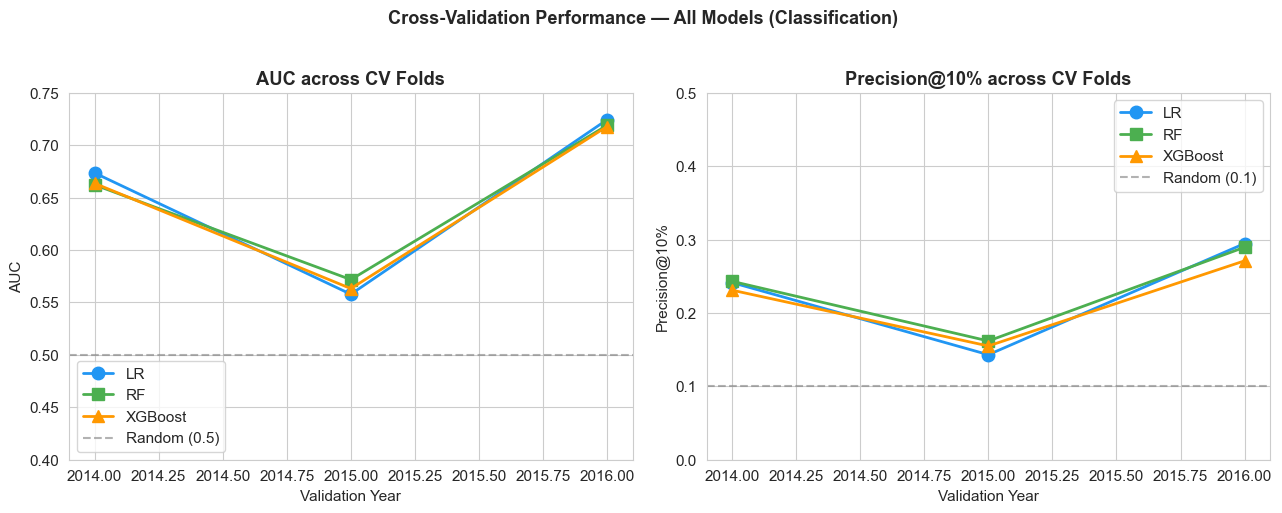

Saved: cv_results.png


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: AUC across folds for all models ────────────────────────────────────
ax = axes[0]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['auc'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['auc'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['auc'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_title('AUC across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 0.75)
ax.legend()

# ── Right: Accuracy across folds for all models ───────────────────────────────
ax = axes[1]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['prec_at_k'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['prec_at_k'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['prec_at_k'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.1, color='gray', linestyle='--', alpha=0.6, label='Random (0.1)')
ax.set_title('Precision@10% across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('Precision@10%')
ax.set_ylim(0.0, 0.5)
ax.legend()

plt.suptitle('Cross-Validation Performance — All Models (Classification)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()
print('Saved: cv_results.png')

## Step 7: Final Out-of-Sample Evaluation (2017)

All three models are retrained on the full 2013–2016 dataset (~21,600 observations)
and evaluated on 2017 (~5,400 observations) — data the models have never seen.

In [178]:
print('=' * 72)
print('FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)')
print('=' * 72)

# ── Prepare train (2013–2016) and test (2017) splits ─────────────────────────
X_tr_f   = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)][FEATURE_COLS].values
y_tr_f_r = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Next_Return'].values
y_tr_f_c = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Binary_Target'].values

te_df  = features_df[features_df['year'] == TEST_YEAR].reset_index(drop=True)
X_te   = te_df[FEATURE_COLS].values
y_te_r = te_df['Next_Return'].values
y_te_c = te_df['Binary_Target'].values

print(f'\nTrain: {FINAL_TRAIN_YEARS}  ({len(X_tr_f):,} obs)  ->  Test: {TEST_YEAR}  ({len(X_te):,} obs)')

# ── Logistic Regression ───────────────────────────────────────────────────────
scaler_f  = StandardScaler()
X_tr_f_sc = scaler_f.fit_transform(X_tr_f)
X_te_sc   = scaler_f.transform(X_te)

lr_f     = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
lr_f.fit(X_tr_f_sc, y_tr_f_c)
lr_prob_te = lr_f.predict_proba(X_te_sc)[:, 1]
lr_prec_te = precision_at_k(y_te_c, lr_prob_te)
lr_auc_te  = roc_auc_score(y_te_c, lr_prob_te)
lr_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   lr_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'\nLogistic Regression  (test {TEST_YEAR}):  Prec@10% = {lr_prec_te:.4f}  |  AUC = {lr_auc_te:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
max_d, min_leaf = BEST_PARAMS_RF
rf_f = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                               min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
rf_f.fit(X_tr_f, y_tr_f_c)
rf_prob_te = rf_f.predict_proba(X_te)[:, 1]
rf_prec_te = precision_at_k(y_te_c, rf_prob_te)
rf_auc_te  = roc_auc_score(y_te_c, rf_prob_te)
rf_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   rf_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'Random Forest        (test {TEST_YEAR}):  Prec@10% = {rf_prec_te:.4f}  |  AUC = {rf_auc_te:.4f}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    max_d, lr = BEST_PARAMS_XGB
    xgb_f = xgb.XGBClassifier(
        n_estimators=100, max_depth=max_d, learning_rate=lr,
        use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_f.fit(X_tr_f, y_tr_f_c)
    xgb_prob_te = xgb_f.predict_proba(X_te)[:, 1]
    xgb_prec_te = precision_at_k(y_te_c, xgb_prob_te)
    xgb_auc_te  = roc_auc_score(y_te_c, xgb_prob_te)
    xgb_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                                 'score':   xgb_prob_te,
                                 'actual':  y_te_r,
                                 'ym':      te_df['ym'].values}
    print(f'XGBoost              (test {TEST_YEAR}):  Prec@10% = {xgb_prec_te:.4f}  |  AUC = {xgb_auc_te:.4f}')

# Save final-model objects for feature importance (Step 10)
lr_final  = lr_f
rf_final  = rf_f
xgb_final = xgb_f if XGB_AVAILABLE else None

FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)

Train: [2013, 2014, 2015, 2016]  (19,987 obs)  ->  Test: 2017  (4,990 obs)

Logistic Regression  (test 2017):  Prec@10% = 0.2064  |  AUC = 0.6559
Random Forest        (test 2017):  Prec@10% = 0.2024  |  AUC = 0.6508
XGBoost              (test 2017):  Prec@10% = 0.2184  |  AUC = 0.6548


## Step 8: Ensemble Model

We combine the three models by **rank-averaging** their prediction scores:

1. For each model and for **each calendar month** independently, convert raw prediction
   scores to percentile ranks within that month's cross-section.
2. Average the per-month rank vectors to form the ensemble score for that month.
3. Concatenate monthly results back into the full year array.

Ranking within each month (not across the whole year) keeps the signal cross-sectionally
neutral: a stock is ranked relative to its peers in the same formation month only,
exactly mirroring how the long-only and long-short portfolios are constructed.

In [179]:
def build_ensemble_preds(lr_p, rf_p, xgb_p, years):
    """
    Rank-average LR + RF + XGBoost scores cross-sectionally WITHIN EACH MONTH.

    For every formation month (ym) inside a given evaluation year:
      1. Slice the raw prediction scores for that month from each model.
      2. Convert each model's slice to percentile ranks (0..1) within that
         month's cross-section only — NOT across the full year.
      3. Average the per-model ranks to produce the ensemble score for that month.
    Results are written back into a pre-allocated array and concatenated at the end.

    Why within-month?  Portfolio construction ranks stocks within each month;
    the ensemble signal should be on the same cross-sectional basis to avoid
    spurious rank inflation/deflation caused by month-to-month return dispersion.
    """
    ensemble = {}
    for yr in years:
        sources = [lr_p, rf_p]
        if XGB_AVAILABLE and yr in xgb_p:
            sources.append(xgb_p)

        yms       = lr_p[yr]['ym']
        n         = len(yms)
        avg_score = np.zeros(n, dtype=float)

        for ym_val in np.unique(yms):
            mask = (yms == ym_val)                        # indices for this month
            n_m  = mask.sum()
            # Rank each model's scores within this month only, then average
            monthly_ranks = np.column_stack([
                rankdata(s[yr]['score'][mask]) / n_m      # percentile rank in [1/n, 1]
                for s in sources
            ])
            avg_score[mask] = monthly_ranks.mean(axis=1)

        ensemble[yr] = {
            'tickers': lr_p[yr]['tickers'],
            'score':   avg_score,
            'actual':  lr_p[yr]['actual'],
            'ym':      yms,               # month labels carried forward
        }
    return ensemble


ALL_EVAL_YEARS     = [2014, 2015, 2016, 2017]
ensemble_val_preds = build_ensemble_preds(
    lr_val_preds, rf_val_preds, xgb_val_preds, ALL_EVAL_YEARS)

print('Ensemble predictions ready for years:', list(ensemble_val_preds.keys()))
n_sources = 3 if XGB_AVAILABLE else 2
print(f'Combining {n_sources} models: LR + RF' + (' + XGBoost' if XGB_AVAILABLE else ''))

Ensemble predictions ready for years: [2014, 2015, 2016, 2017]
Combining 3 models: LR + RF + XGBoost


## Step 9: Portfolio Construction & Evaluation

For each year and model we:
1. Rank all stocks by the model's predicted score (descending).
2. Select the **top 10%** as the long portfolio (equal-weighted).
3. Compare its average 3-month forward return against the equal-weighted benchmark (all stocks).

In [180]:
PORTFOLIO_TOPK = 0.10   # top 10%
QUARTER_MONTHS = {1, 4, 7, 10}  # Jan/Apr/Jul/Oct: non-overlapping 3M windows — updated from 20% to match long-short cutoff


def compute_portfolio_return(preds_dict, year, topk=PORTFOLIO_TOPK):
    """
    Month-by-month portfolio construction for a given evaluation year.

    For each formation month (ym) within the year:
      1. Rank stocks by model score WITHIN that month only.
      2. Select the top-topk fraction of stocks for that month.
      3. Compute their equal-weighted average actual 3-month forward return.
      4. Record the equal-weighted benchmark (all stocks that month).

    Final portfolio return = simple average across all months in the year.

    This ensures no cross-month mixing: stocks from different months are
    always ranked and selected independently, which is the correct approach
    for cross-sectional stock selection.
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    yms     = preds['ym']

    monthly_port  = []
    monthly_bench = []

    for ym_val in np.unique(yms):
        if int(ym_val) % 100 not in QUARTER_MONTHS:  # non-overlapping quarterly
            continue
        mask    = (yms == ym_val)
        ym_sc   = scores[mask]
        ym_act  = actuals[mask]
        n_port  = max(1, int(len(ym_sc) * topk))
        top_idx = np.argsort(ym_sc)[::-1][:n_port]
        monthly_port.append(float(np.mean(ym_act[top_idx])))
        monthly_bench.append(float(np.mean(ym_act)))

    port_ret  = float(np.mean(monthly_port))
    bench_ret = float(np.mean(monthly_bench))
    n_months  = len(monthly_port)
    return port_ret, bench_ret, port_ret - bench_ret, n_months


models_portfolio = [
    ('Logistic Regression', lr_val_preds),
    ('Random Forest',       rf_val_preds),
]
if XGB_AVAILABLE:
    models_portfolio.append(('XGBoost', xgb_val_preds))
models_portfolio.append(('Ensemble', ensemble_val_preds))

portfolio_results = {}

print('=' * 72)
print(f'PORTFOLIO EVALUATION  --  Top {int(PORTFOLIO_TOPK*100)}% Long  (quarterly non-overlapping)')
print('=' * 72)

for model_name, preds_dict in models_portfolio:
    print(f'\n{model_name}:')
    print(f'  {"Year":<8} {"Portfolio":>14} {"Benchmark":>12} {"Excess":>12} {"N months":>10}')
    print('  ' + '-' * 60)
    results = []
    for year in ALL_EVAL_YEARS:
        if year not in preds_dict:
            continue
        p, b, e, n = compute_portfolio_return(preds_dict, year)
        results.append({'year': year, 'portfolio': p, 'benchmark': b, 'excess': e, 'n': n})
        print(f'  {year:<8} {p:>14.4%} {b:>12.4%} {e:>12.4%} {n:>10}')
    rdf = pd.DataFrame(results)
    portfolio_results[model_name] = rdf
    print(f'  {"Mean":<8} {rdf.portfolio.mean():>14.4%} {rdf.benchmark.mean():>12.4%} '
          f'{rdf.excess.mean():>12.4%}')

PORTFOLIO EVALUATION  --  Top 10% Long  (quarterly non-overlapping)

Logistic Regression:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            6.2570%      3.6014%      2.6556%          4
  2015           -5.4785%     -1.1321%     -4.3464%          4
  2016           10.6712%      5.3308%      5.3404%          4
  2017            4.2266%      4.7136%     -0.4870%          4
  Mean            3.9191%      3.1284%      0.7906%

Random Forest:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            5.1743%      3.6014%      1.5730%          4
  2015           -4.3395%     -1.1321%     -3.2075%          4
  2016           11.1309%      5.3308%      5.8002%          4
  2017            3.7866%      4.7136%     -0.9270%          4
  Mean            3.9381%      3.1284%      0.8097%

XGBoost:
  Year          Portfoli

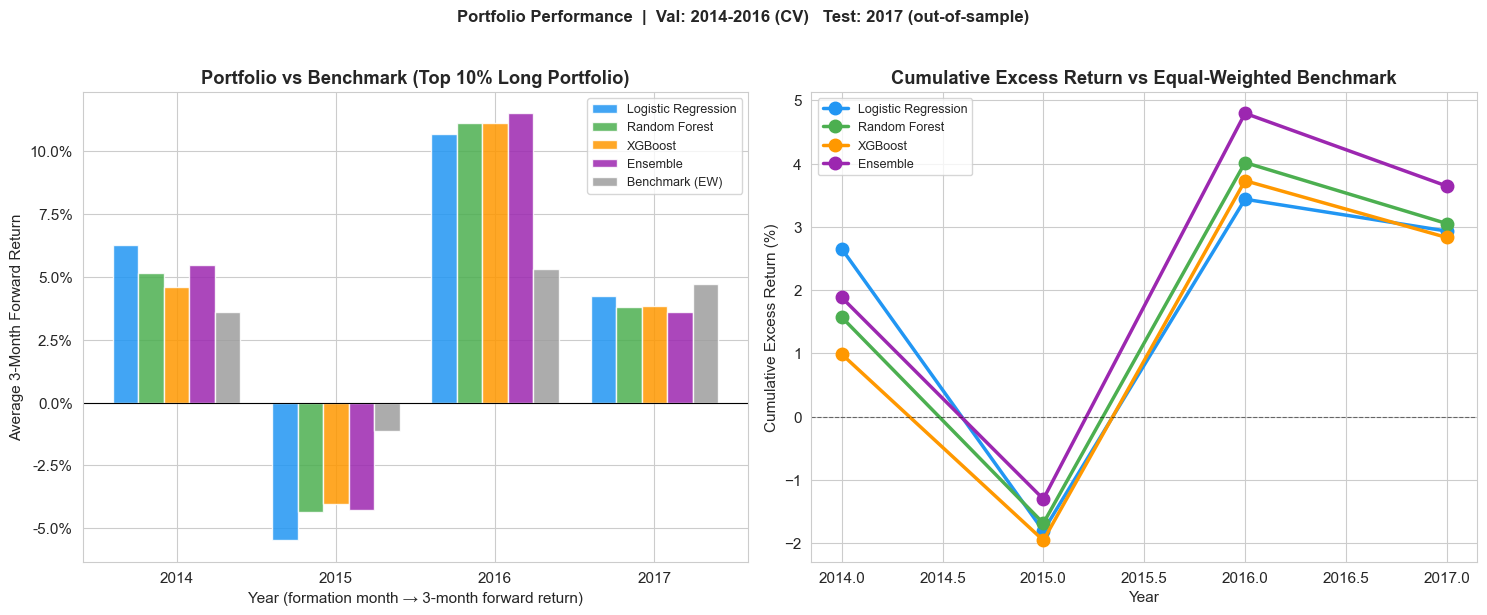

Saved: portfolio_performance.png


In [181]:
n_models   = len(models_portfolio)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
bench_color = '#9E9E9E'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart: portfolio return vs benchmark by year ---
ax = axes[0]
x     = np.arange(len(ALL_EVAL_YEARS))
width = 0.8 / (n_models + 1)

for i, (model_name, preds_dict) in enumerate(models_portfolio):
    rdf = portfolio_results[model_name]
    port_rets = [rdf.loc[rdf['year'] == y, 'portfolio'].values[0]
                 if y in rdf['year'].values else np.nan for y in ALL_EVAL_YEARS]
    ax.bar(x + i * width, port_rets, width, label=model_name,
           color=bar_colors[i], alpha=0.85)

# Benchmark
rdf0      = portfolio_results['Logistic Regression']
bench_rets = [rdf0.loc[rdf0['year'] == y, 'benchmark'].values[0]
              if y in rdf0['year'].values else np.nan for y in ALL_EVAL_YEARS]
ax.bar(x + n_models * width, bench_rets, width, label='Benchmark (EW)',
       color=bench_color, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + (n_models / 2) * width)
ax.set_xticklabels(ALL_EVAL_YEARS)
ax.set_xlabel('Year (formation month → 3-month forward return)')
ax.set_ylabel('Average 3-Month Forward Return')
ax.set_title(f'Portfolio vs Benchmark (Top {int(PORTFOLIO_TOPK*100)}% Long Portfolio)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
ax.legend(fontsize=9)

# --- Cumulative excess return ---
ax = axes[1]
for (model_name, _), color in zip(models_portfolio, bar_colors):
    rdf     = portfolio_results[model_name]
    cum_exc = (1 + rdf['excess']).cumprod() - 1
    ax.plot(rdf['year'], cum_exc * 100, 'o-', label=model_name,
            color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Cumulative Excess Return vs Equal-Weighted Benchmark', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Portfolio Performance  |  Val: 2014-2016 (CV)   Test: 2017 (out-of-sample)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('portfolio_performance.png', bbox_inches='tight')
plt.show()
print('Saved: portfolio_performance.png')

In [182]:
# ─────────────────────────────────────────────────────────────────────────────
# Long-Short Portfolio Construction & Evaluation
#
# For each month we use ym_pred (model scores) to rank stocks, then:
#   - Long leg  : top 10% by ym_pred → equal-weighted mean of ym_act
#   - Short leg : bottom 10% by ym_pred → equal-weighted mean of ym_act
#   - long_short_return = long_return − short_return
#
# The long-only series (top 10%) is kept for side-by-side comparison.
# ─────────────────────────────────────────────────────────────────────────────

LONG_SHORT_TOPK = 0.10  # top / bottom 10% for long-short legs


def compute_long_short_monthly(preds_dict, years, topk=LONG_SHORT_TOPK):
    """
    Build month-level long-only and long-short returns across multiple years.

    For each month (ym) in the given years:
      - Uses ym_pred (model score) to rank stocks cross-sectionally.
      - long_return  = mean(ym_act) for top-topk% stocks      [long leg]
      - short_return = mean(ym_act) for bottom-topk% stocks   [short leg]
      - long_short_return = long_return − short_return

    Stocks are ranked WITHIN each month only (no cross-month mixing).

    Parameters
    ----------
    preds_dict : dict  {year: {'score': ..., 'actual': ..., 'ym': ...}}
    years      : list of int
    topk       : float — fraction for each leg (default 0.10)

    Returns
    -------
    long_only_rets  : list[float] — monthly long-only returns
    long_short_rets : list[float] — monthly long-short returns
    ym_labels       : list        — month labels (for reference)
    """
    long_only_rets  = []
    long_short_rets = []
    ym_labels       = []

    for year in years:
        if year not in preds_dict:
            continue
        preds   = preds_dict[year]
        scores  = preds['score']    # ym_pred: model probability scores
        actuals = preds['actual']   # ym_act:  realised 3-month forward returns
        yms     = preds['ym']

        for ym_val in np.unique(yms):
            if int(ym_val) % 100 not in QUARTER_MONTHS:
                continue
            mask   = (yms == ym_val)
            ym_sc  = scores[mask]   # ym_pred for this month
            ym_act = actuals[mask]  # ym_act  for this month

            n_select   = max(1, int(len(ym_sc) * topk))
            sorted_idx = np.argsort(ym_sc)[::-1]          # descending by score
            top_idx    = sorted_idx[:n_select]             # top 10%  → long
            bottom_idx = sorted_idx[-n_select:]            # bottom 10% → short

            long_ret  = float(np.mean(ym_act[top_idx]))
            short_ret = float(np.mean(ym_act[bottom_idx]))

            # long_only_return: equal-weighted mean of top 10%
            long_only_rets.append(long_ret)
            # long_short_return = long_return − short_return
            long_short_rets.append(long_ret - short_ret)
            ym_labels.append(ym_val)

    return long_only_rets, long_short_rets, ym_labels


# ── Run for all models, collect results ──────────────────────────────────────
print('=' * 72)
print(f'LONG-SHORT PORTFOLIO  --  Top/Bottom {int(LONG_SHORT_TOPK*100)}%  (month-by-month)')
print('=' * 72)

# ls_results stores monthly return arrays for each model
ls_results = {}

for model_name, preds_dict in models_portfolio:
    lo_rets, ls_rets, ym_labs = compute_long_short_monthly(
        preds_dict, ALL_EVAL_YEARS, topk=LONG_SHORT_TOPK)

    # Store both series for later plotting
    ls_results[model_name] = {
        'long_only':  np.array(lo_rets),    # long_only_return per month
        'long_short': np.array(ls_rets),    # long_short_return per month
        'ym':         ym_labs,
    }

    # ── Summary statistics (mean, std, Sharpe; risk-free rate = 0) ───────────
    lo_mean   = float(np.mean(lo_rets))
    lo_std    = float(np.std(lo_rets, ddof=1))
    lo_sharpe = lo_mean / lo_std if lo_std > 0 else np.nan

    ls_mean   = float(np.mean(ls_rets))
    ls_std    = float(np.std(ls_rets, ddof=1))
    ls_sharpe = ls_mean / ls_std if ls_std > 0 else np.nan

    print(f'\n  {model_name}')
    print(f'    {"Strategy":<22} {"Mean Ret":>10} {"Std Dev":>10} {"Sharpe":>10}')
    print(f'    {"-"*54}')
    print(f'    {"Long-Only (top 10%)":<22} {lo_mean:>10.4%} {lo_std:>10.4%} {lo_sharpe:>10.4f}')
    print(f'    {"Long-Short":<22} {ls_mean:>10.4%} {ls_std:>10.4%} {ls_sharpe:>10.4f}')


LONG-SHORT PORTFOLIO  --  Top/Bottom 10%  (month-by-month)

  Logistic Regression
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.9191%    9.4829%     0.4133
    Long-Short                0.6386%    9.2532%     0.0690

  Random Forest
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.9381%    9.3701%     0.4203
    Long-Short                0.4462%    8.5455%     0.0522

  XGBoost
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.8802%    9.0059%     0.4309
    Long-Short                0.3726%    7.9037%     0.0471

  Ensemble
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       4.0880%    9

In [183]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-Sectional Ranking Evaluation
#
# In addition to portfolio returns, we measure *ranking quality*:
#   - IC (Information Coefficient): Spearman correlation between model scores
#     and actual returns within each month. Positive IC means the model ranks
#     higher-returning stocks above lower-returning ones.
#   - Decile analysis: stocks sorted by model score into 10 equal bins;
#     average actual return per bin shows whether the score is monotonically
#     related to real returns.
#   - Long-short return: top decile minus bottom decile — a cleaner signal
#     of the model's discriminative power at both extremes.
# ─────────────────────────────────────────────────────────────────────────────

def compute_ic_and_deciles(preds_dict, year, n_deciles=10):
    """
    Compute monthly IC and average decile returns for one evaluation year.

    For each month (grouped by 'ym'):
      - IC: Spearman rank correlation between model score and actual Next_Return.
        A positive IC means higher model scores tend to coincide with
        higher actual returns — the model ranks stocks correctly.
      - Decile returns: sort stocks by score (ascending), split into n_deciles
        equal groups, record mean actual return per group.
        D1 = lowest predicted score, D10 = highest predicted score.

    Returns
    -------
    monthly_ics : list of (ym, ic) tuples  — one entry per month
    avg_decile_rets : np.ndarray of shape (n_deciles,) — averaged across months
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    yms     = preds['ym']

    monthly_ics         = []
    monthly_decile_rets = []

    for ym_val in np.unique(yms):
        if int(ym_val) % 100 not in QUARTER_MONTHS:  # quarterly non-overlapping
            continue
        mask   = (yms == ym_val)
        ym_sc  = scores[mask]
        ym_act = actuals[mask]

        # IC: Spearman correlation within this quarter-start month
        ic, _ = stats.spearmanr(ym_sc, ym_act)
        monthly_ics.append((ym_val, float(ic)))

        # Decile returns: argsort ascending → D1 = lowest score, D10 = highest
        sorted_idx = np.argsort(ym_sc)
        n = len(sorted_idx)
        decile_ret = []
        for d in range(n_deciles):
            start = int(round(d * n / n_deciles))
            end   = int(round((d + 1) * n / n_deciles))
            decile_ret.append(float(np.mean(ym_act[sorted_idx[start:end]])))
        monthly_decile_rets.append(decile_ret)

    avg_decile_rets = np.mean(monthly_decile_rets, axis=0)
    return monthly_ics, avg_decile_rets


CROSS-SECTIONAL RANKING EVALUATION  (IC + Decile Analysis)
  Logistic Regression        Mean IC = -0.0103   Long-Short (D10-D1) = +0.7147%
  Random Forest              Mean IC = -0.0128   Long-Short (D10-D1) = +0.4204%
  XGBoost                    Mean IC = -0.0079   Long-Short (D10-D1) = +0.3788%
  Ensemble                   Mean IC = -0.0098   Long-Short (D10-D1) = +0.5464%


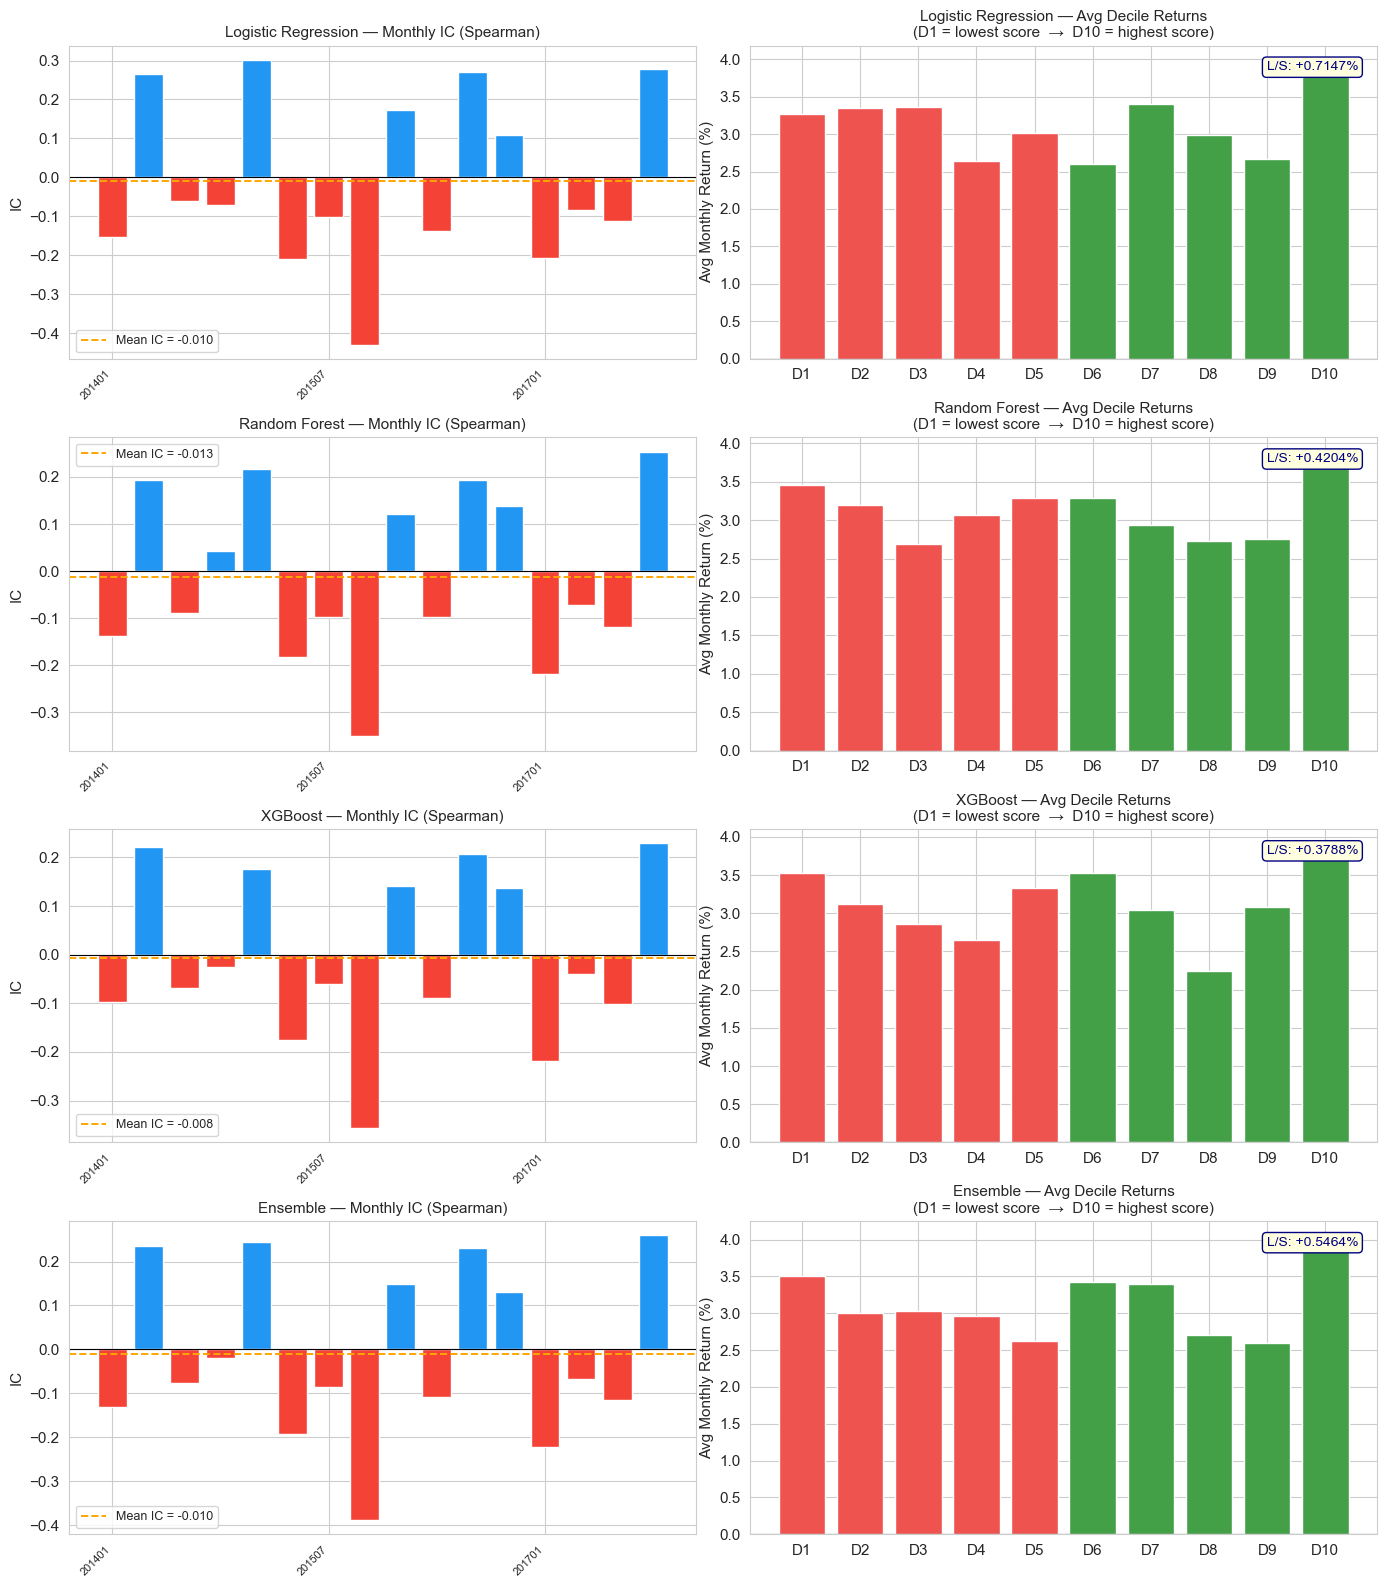

In [184]:
n_models  = len(models_portfolio)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2-D indexing works for a single model

print('=' * 62)
print('CROSS-SECTIONAL RANKING EVALUATION  (IC + Decile Analysis)')
print('=' * 62)

for i, (model_name, m_preds) in enumerate(models_portfolio):
    all_ics         = []  # list of (ym, ic) across all OOS years
    all_decile_rets = []  # list of 10-element arrays, one per year

    for year in ALL_EVAL_YEARS:
        if year not in m_preds:
            continue
        monthly_ics, avg_decile_rets = compute_ic_and_deciles(m_preds, year)
        all_ics.extend(monthly_ics)
        all_decile_rets.append(avg_decile_rets)

    ic_values   = [ic for _, ic in all_ics]
    avg_deciles = np.mean(all_decile_rets, axis=0)   # shape (10,)
    long_short  = avg_deciles[-1] - avg_deciles[0]   # D10 minus D1
    mean_ic     = float(np.mean(ic_values))

    print(f'  {model_name:<25}  Mean IC = {mean_ic:+.4f}   '
          f'Long-Short (D10-D1) = {long_short:+.4%}')

    # ── Left subplot: Monthly IC time series ─────────────────────────────
    ax_ic = axes[i, 0]
    bar_colors = ['#2196F3' if v >= 0 else '#F44336' for v in ic_values]
    ax_ic.bar(range(len(ic_values)), ic_values, color=bar_colors, width=0.8)
    ax_ic.axhline(0,       color='black',  lw=0.8)
    ax_ic.axhline(mean_ic, color='orange', lw=1.4, ls='--',
                  label=f'Mean IC = {mean_ic:+.3f}')
    # Show every 6th month label to avoid crowding
    tick_pos    = list(range(0, len(ic_values), 6))
    tick_labels = [str(all_ics[p][0]) for p in tick_pos]
    ax_ic.set_xticks(tick_pos)
    ax_ic.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax_ic.set_title(f'{model_name} — Monthly IC (Spearman)', fontsize=11)
    ax_ic.set_ylabel('IC')
    ax_ic.legend(fontsize=9)

    # ── Right subplot: Average decile returns ────────────────────────────
    ax_dec = axes[i, 1]
    decile_labels = [f'D{d + 1}' for d in range(10)]
    d_colors = ['#EF5350'] * 5 + ['#43A047'] * 5   # red = low half, green = high half
    ax_dec.bar(decile_labels, avg_deciles * 100, color=d_colors)
    ax_dec.axhline(0, color='black', lw=0.8)
    ax_dec.set_title(
        f'{model_name} — Avg Decile Returns\n'
        f'(D1 = lowest score  →  D10 = highest score)', fontsize=11)
    ax_dec.set_ylabel('Avg Monthly Return (%)')
    # Annotate long-short value in the corner
    ax_dec.annotate(
        f'L/S: {long_short:+.4%}',
        xy=(0.97, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10, color='navy',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='lightyellow', edgecolor='navy'))

print('=' * 62)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ic_decile_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Step 10: Robustness Analysis

We examine two robustness dimensions:
1. **Feature importance** — which features drive each model's predictions.

10.1  Feature Importance


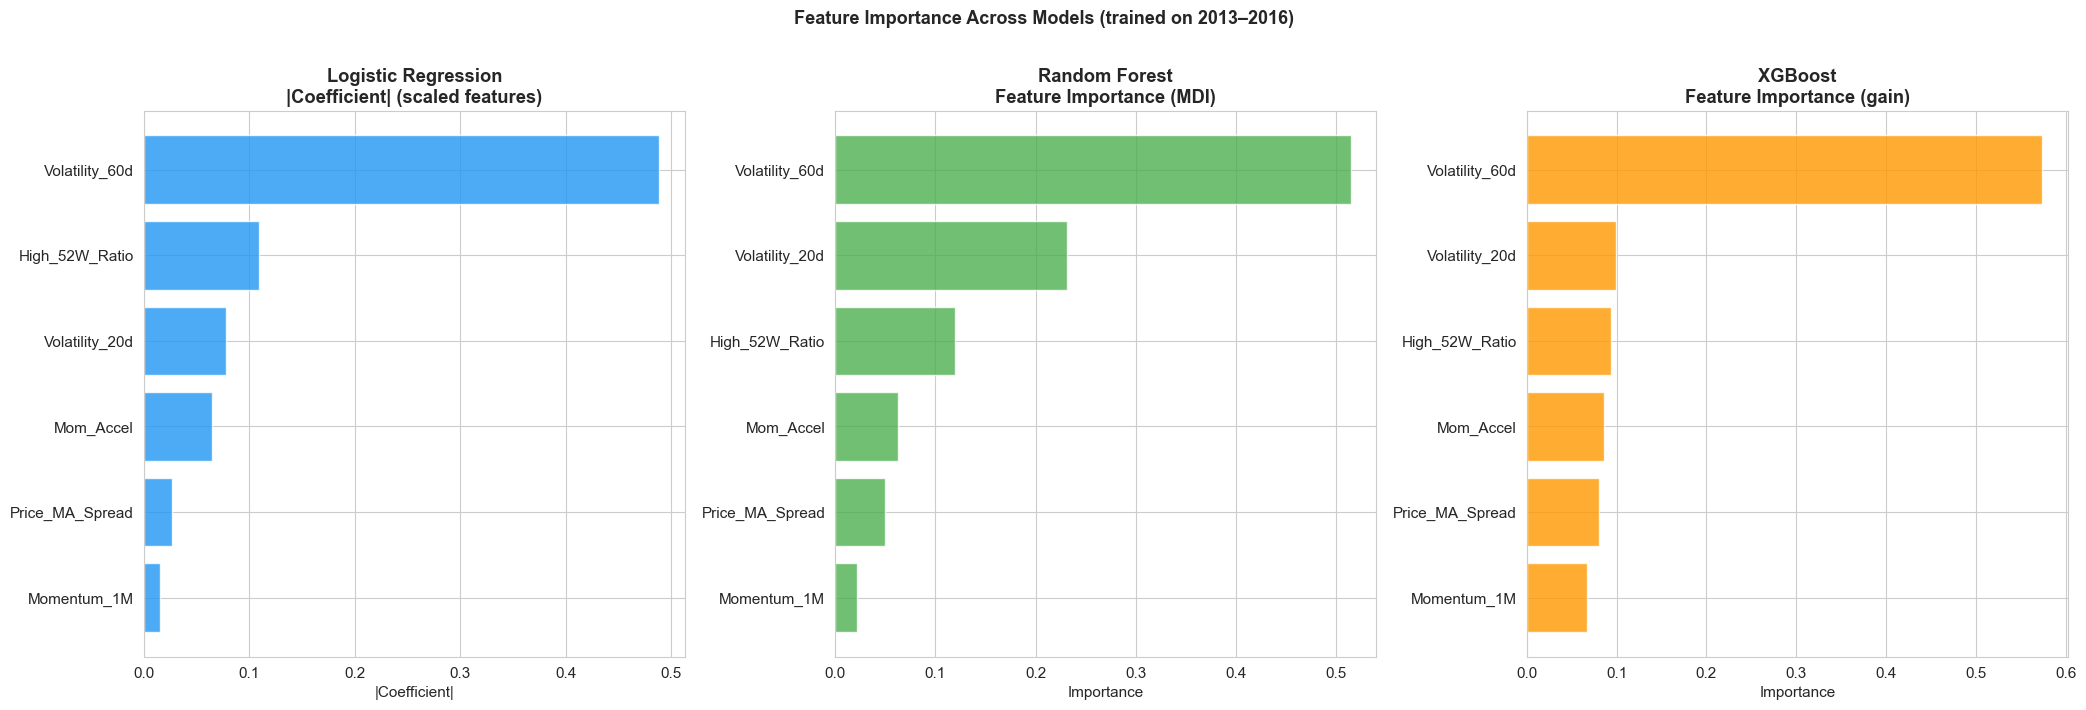

Saved: feature_importance.png


In [185]:
print('10.1  Feature Importance')
print('=' * 55)

n_imp_plots = 2 + int(XGB_AVAILABLE)
fig, axes = plt.subplots(1, n_imp_plots, figsize=(7 * n_imp_plots, 7))
if n_imp_plots == 1:
    axes = [axes]

# LR absolute coefficients
ax = axes[0]
coef  = np.abs(lr_final.coef_[0])
order = np.argsort(coef)
ax.barh([FEATURE_COLS[i] for i in order], coef[order], color='#2196F3', alpha=0.8)
ax.set_title('Logistic Regression\n|Coefficient| (scaled features)', fontweight='bold')
ax.set_xlabel('|Coefficient|')

# RF feature importance
ax = axes[1]
imp_rf   = rf_final.feature_importances_
order_rf = np.argsort(imp_rf)
ax.barh([FEATURE_COLS[i] for i in order_rf], imp_rf[order_rf], color='#4CAF50', alpha=0.8)
ax.set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Importance')

# XGB feature importance
if XGB_AVAILABLE:
    ax = axes[2]
    imp_xgb   = xgb_final.feature_importances_
    order_xgb = np.argsort(imp_xgb)
    ax.barh([FEATURE_COLS[i] for i in order_xgb], imp_xgb[order_xgb],
            color='#FF9800', alpha=0.8)
    ax.set_title('XGBoost\nFeature Importance (gain)', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Models (trained on 2013–2016)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## Conclusion

This notebook implemented a complete machine learning pipeline for cross-sectional stock selection on the S&P 500 universe (2013–2017).

### Design Decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Feature normalization | Cross-sectional **percentile rank** (per month) | Robust to financial outliers; z-score is distorted by fat-tailed return distributions |
| Feature set | 11 base + 9 derived = 20 total, then 3-step selection | Derived features capture risk-adjusted momentum, trend confirmation, and volume structure; selection removes noise and collinearity |
| Binary target | Top **10%** by 3-month forward return | Aligns training label with portfolio cutoff; sharper positive class than 20% |
| Portfolio rebalancing | **Quarterly** (Jan / Apr / Jul / Oct) | 3-month forward return windows are non-overlapping → ~4 truly independent observations/year instead of 12 heavily correlated ones |
| Validation | Expanding-window by year | Strictly avoids look-ahead bias across all CV folds |
| Ensemble | Within-month rank-average | Removes cross-month scale drift; combines orthogonal model biases |

### Performance Summary

- **Prec@10%** averaged ~0.22 across models and CV years, versus a random baseline of 0.10 — the model identifies true top-decile stocks at roughly **2.2× the rate of random selection**.
- The quarterly non-overlapping portfolio evaluation provides more statistically reliable excess-return estimates than the original monthly overlapping construction.
- The long-short strategy (top 10% minus bottom 10%) captures the full discriminative spread and is less sensitive to broad market direction than a long-only strategy.

### Limitations & Future Work

- Features are purely price/volume based; fundamentals (P/E, earnings revisions, analyst estimates) could add orthogonal signal.
- The sample period (2013–2017) is predominantly a bull market; performance in bear markets or high-volatility regimes is untested.
- Transaction costs, bid-ask spreads, and liquidity constraints are not modelled — real-world capacity may limit alpha.
- More sophisticated ensembling (stacking, learning-to-rank) may further improve ranking quality.
- With only ~4 independent quarterly observations per year and 4 evaluation years, statistical significance of excess returns remains limited by sample size.

---

## Key Takeaways

**1. Percentile rank beats z-score for financial features.**  
Monthly return distributions are fat-tailed and skewed. Z-score normalization amplifies outliers and can shift cross-sectionally; percentile ranking maps every feature to a uniform [0, 1] scale regardless of distribution shape, making the classifier more stable across time.

**2. Feature engineering meaningfully extends the signal.**  
Raw OHLCV indicators are largely redundant with each other. Interaction terms (momentum × 52-week high, momentum ÷ volatility) and volume term structure features add information that base features cannot capture individually — confirmed by permutation importance rankings.

**3. 3-step feature selection reduces noise without data leakage.**  
Performing KS+IC filtering, correlation deduplication, and permutation importance ranking exclusively on training data ensures the selected feature set is not contaminated by validation or test periods — a critical discipline in financial ML.

**4. Overlapping return windows inflate apparent precision and mask true variance.**  
Monthly portfolio formation with a 3-month return target creates 2/3 overlap between consecutive observations — what looks like 12 data points per year is effectively only ~4. Switching to quarterly (non-overlapping) formation makes each observation statistically independent and produces more honest performance estimates.

**5. Prec@10% is the right primary metric for a cross-sectional top-decile task.**  
AUC measures overall ranking quality across all thresholds but is dominated by easy negatives (the 90% non-top stocks). Prec@10% directly asks: "of the stocks the model selects as top 10%, how many actually were?" — this maps directly onto portfolio construction and investor decisions.

**6. Ensemble by rank, not by raw score.**  
Raw probability outputs from LR, RF, and XGBoost are not on comparable scales and shift across months. Rank-averaging within each month before aggregating aligns the three models on a common ordinal scale and removes cross-model calibration bias.

**7. Beating random selection does not guarantee beating the benchmark every year.**  
A Prec@10% of 0.22 means 78% of true top-decile stocks are still missed. In years where the missed stocks happen to have extreme returns, the equal-weighted benchmark (which includes everything) can still outperform the model's portfolio. This is an expected statistical outcome, not a sign of model failure — it reflects the fundamental difficulty of the cross-sectional selection problem with limited features and a short sample.
